[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/subramanyanaik/schoolofai_subbu/blob/main/assignment10/truth_harness.ipynb)

Generated from [`truth_harness.py`](truth_harness.py) by `tools/build_notebook.py` - edit the `.py`, not this file.

# Session 10 — Make the training step tell you the truth about itself

A small GPT (nanoGPT's architecture, written out here so every tensor is reachable) and a
real training loop, instrumented until it stops being a black box. Six questions, each
answered by a measurement rather than by an assertion in prose:

1. **Every tensor shape in the step**, with one line per tensor saying what each axis means.
2. **One gradient verified by hand** — nudge a weight, watch the loss move, compare against
   what `backward()` reported.
3. **Gradient accumulation broken on purpose** — the average of the averages, with
   micro-batches of different lengths, plotted against the correct rule.
4. **Grad norm logged at every step**, and one step located where it moved before the loss did.
5. **MFU computed and reported honestly**, with the distance to 40% attributed to measured
   causes rather than guessed ones.
6. **0.1 written out by hand in fp32, bf16 and fp8 E4M3**, bit by bit, and a decision about
   which one to train in.

This file is the single source of truth. `tools/build_notebook.py` turns it, cell for cell,
into `truth_harness.ipynb`, and CI fails if the two drift apart. Every number quoted in
`README.md` is read out of `results/results.json`, which this run writes.

In [1]:
# ---------------------------------------------------------------------------------------
# Setup.  torch, numpy, matplotlib and tiktoken; everything else is stdlib.
# ---------------------------------------------------------------------------------------
import json
import math
import os
import struct
import subprocess
import sys
import time
import urllib.request
from dataclasses import dataclass, asdict

try:
    import tiktoken
except ImportError:                       # Colab
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tiktoken"], check=True)
    import tiktoken

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
IN_NOTEBOOK = "ipykernel" in sys.modules
if not IN_NOTEBOOK:                       # headless script run
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def show(fig):
    """Display inline in a notebook; close silently in a headless script run."""
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(fig)


RESULTS = {}          # every number the write-up quotes ends up in here

try:                                      # running as a script
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:                         # running as a notebook
    HERE = os.getcwd()
OUT_DIR = os.path.join(HERE, "results")
os.makedirs(OUT_DIR, exist_ok=True)


T_START = time.time()
if not IN_NOTEBOOK:                       # so a redirected log is UTF-8, not cp1252
    try:
        sys.stdout.reconfigure(encoding="utf-8")
    except Exception:
        pass


def rule(title):
    el = time.time() - T_START
    print("\n" + "=" * 92)
    print(f"{title}   [t+{int(el) // 60:d}m{int(el) % 60:02d}s]")
    print("=" * 92)


def record(key, value):
    RESULTS[key] = value
    return value


SEED = 1337
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

rule("Environment")
print(f"python        : {sys.version.split()[0]}")
print(f"torch         : {torch.__version__}")
print(f"device        : {device}")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"gpu           : {props.name}  ({props.total_memory / 2**30:.2f} GiB, "
          f"{props.multi_processor_count} SMs, sm_{props.major}{props.minor})")
    record("gpu", props.name)
    record("gpu_total_gib", round(props.total_memory / 2**30, 2))
    record("gpu_sms", props.multi_processor_count)
    record("gpu_cc", f"{props.major}.{props.minor}")
else:
    record("gpu", None)
record("torch_version", torch.__version__)
record("seed", SEED)


Environment   [t+0m01s]
python        : 3.12.6
torch         : 2.5.1+cu121
device        : cuda
gpu           : NVIDIA GeForce RTX 3050 Laptop GPU  (4.00 GiB, 16 SMs, sm_86)


1337

## 0. The model and the data

nanoGPT's architecture, transcribed rather than imported, for one reason: section 1 has to
print *every* tensor in the step, and that means the intermediates inside attention have to
be reachable. `F.scaled_dot_product_attention` never materialises the `[B, nh, T, T]`
score matrix — that is exactly why it is fast — so the model keeps both paths and switches
to the explicit one only while tracing. Section 1 checks that the two agree.

In [2]:
enc = tiktoken.get_encoding("gpt2")
VOCAB_SIZE = enc.n_vocab                  # 50257
IGNORE = -100                             # target-side "this position does not count"


@dataclass
class Config:
    vocab_size: int = VOCAB_SIZE
    block_size: int = 128                 # T: the longest sequence the model can see
    n_layer: int = 4                      # L
    n_head: int = 4                       # nh
    n_embd: int = 256                     # C, and hs = C / nh = 64
    dropout: float = 0.0
    bias: bool = True


cfg = Config()

# Section 2 flips this on.  `F.scaled_dot_product_attention` picks its own kernel, and on
# this torch build the CPU fused kernel returns NaN in float64 (demonstrated, with a minimal
# repro, at the top of section 2).  The finite-difference check needs float64, so it needs a
# way to ask for the explicit arithmetic.  Section 1 proves the two paths agree.
EXPLICIT_ATTENTION = False


class CausalSelfAttention(nn.Module):
    def __init__(self, c):
        super().__init__()
        assert c.n_embd % c.n_head == 0
        self.n_head, self.n_embd = c.n_head, c.n_embd
        self.dropout = c.dropout
        self.c_attn = nn.Linear(c.n_embd, 3 * c.n_embd, bias=c.bias)
        self.c_proj = nn.Linear(c.n_embd, c.n_embd, bias=c.bias)
        self.attn_dropout = nn.Dropout(c.dropout)
        self.resid_dropout = nn.Dropout(c.dropout)
        self.register_buffer(
            "mask", torch.tril(torch.ones(c.block_size, c.block_size))
                         .view(1, 1, c.block_size, c.block_size))

    def forward(self, x, tr=None):
        B, T, C = x.shape
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        hs = C // self.n_head
        q = q.view(B, T, self.n_head, hs).transpose(1, 2)      # [B, nh, T, hs]
        k = k.view(B, T, self.n_head, hs).transpose(1, 2)
        v = v.view(B, T, self.n_head, hs).transpose(1, 2)
        if tr is None and not EXPLICIT_ATTENTION:
            # The fast path: flash / memory-efficient attention.  No [B,nh,T,T] ever exists.
            y = F.scaled_dot_product_attention(
                q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=True)
        else:
            # The explicit path: used while tracing, so the scores can be printed, and in
            # float64, where the fused kernel is unusable.
            scores = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(hs))
            masked = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
            att = F.softmax(masked, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v
        if tr is not None:
            tr("attn.qkv", qkv, "3C=768 -> query, key and value for every position, "
                                "concatenated so one matmul produces all three")
            tr("attn.q", q, "nh=4 heads, each reading the same T positions in its own "
                            "hs=64-wide subspace")
            tr("attn.k", k, "one key vector per head per position")
            tr("attn.v", v, "one value vector per head per position")
            tr("attn.scores", scores, "T x T -> for each query position (3rd axis), its raw "
                                      "affinity to every key position (4th axis)")
            tr("attn.probs", att, "the same T x T after causal masking and softmax; each row "
                                  "sums to 1 over the positions at or before it")
            tr("attn.out_heads", y, "per head, the value vectors averaged under those "
                                    "probabilities")
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        if tr is not None:
            tr("attn.out_merged", y, "the nh heads concatenated back into one C-wide vector "
                                     "per position")
        y = self.resid_dropout(self.c_proj(y))
        if tr is not None:
            tr("attn.out_proj", y, "attention's contribution to the residual stream")
        return y


class MLP(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c_fc = nn.Linear(c.n_embd, 4 * c.n_embd, bias=c.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * c.n_embd, c.n_embd, bias=c.bias)
        self.dropout = nn.Dropout(c.dropout)

    def forward(self, x, tr=None):
        h = self.c_fc(x)
        if tr is not None:
            tr("mlp.fc", h, "4C=1024 -> the widened per-position feature vector; the same "
                            "matmul applied independently at every one of the B*T positions")
        h = self.gelu(h)
        if tr is not None:
            tr("mlp.gelu", h, "elementwise, so the shape cannot change")
        out = self.dropout(self.c_proj(h))
        if tr is not None:
            tr("mlp.out", out, "projected back to C, the MLP's contribution to the residual")
        return out


class Block(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.ln_1 = nn.LayerNorm(c.n_embd, elementwise_affine=True)
        self.attn = CausalSelfAttention(c)
        self.ln_2 = nn.LayerNorm(c.n_embd, elementwise_affine=True)
        self.mlp = MLP(c)

    def forward(self, x, tr=None):
        n1 = self.ln_1(x)
        if tr is not None:
            tr("ln_1", n1, "normalised over C for each of the B*T positions independently")
        x = x + self.attn(n1, tr)
        if tr is not None:
            tr("resid_after_attn", x, "the residual stream, unchanged in shape all the way "
                                      "through the model")
        n2 = self.ln_2(x)
        if tr is not None:
            tr("ln_2", n2, "normalised over C again, before the MLP")
        x = x + self.mlp(n2, tr)
        if tr is not None:
            tr("resid_after_mlp", x, "the residual stream leaving this block")
        return x


class GPT(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.config = c
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(c.vocab_size, c.n_embd),
            wpe=nn.Embedding(c.block_size, c.n_embd),
            drop=nn.Dropout(c.dropout),
            h=nn.ModuleList([Block(c) for _ in range(c.n_layer)]),
            ln_f=nn.LayerNorm(c.n_embd, elementwise_affine=True),
        ))
        self.lm_head = nn.Linear(c.n_embd, c.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight       # weight tying
        self.apply(self._init)
        for pn, p in self.named_parameters():                   # nanoGPT's residual scaling
            if pn.endswith("c_proj.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * c.n_layer))

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None, tr=None, reduction="mean"):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        tok = self.transformer.wte(idx)
        pe = self.transformer.wpe(pos)
        if tr is not None:
            tr("input_ids", idx, "B=rows in this micro-batch, T=positions per row; every "
                                 "entry is one integer token id")
            tr("pos", pos, "T position indices, 0..T-1, shared by every row")
            tr("tok_emb", tok, "each of the B*T ids replaced by its C-wide row of wte")
            tr("pos_emb", pe, "one C-wide vector per position, broadcast across the B rows")
        x = self.transformer.drop(tok + pe)
        if tr is not None:
            tr("x_in", x, "the residual stream entering block 0")
        for i, blk in enumerate(self.transformer.h):
            trace_this = tr if (tr is not None and tr.layer == i) else None
            x = blk(x, trace_this)
            if tr is not None and trace_this is None:
                tr(f"block[{i}].out", x, f"block {i} traced only at its output; its interior "
                                         f"is identical in shape to block {tr.layer}")
        x = self.transformer.ln_f(x)
        if tr is not None:
            tr("ln_f", x, "the final normalisation, still one C-wide vector per position")
        logits = self.lm_head(x)
        if tr is not None:
            tr("logits", logits, "V=50257 -> one real number per vocabulary entry per "
                                 "position; the widest tensor in the step")
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1),
                                   ignore_index=IGNORE, reduction=reduction)
            if tr is not None:
                tr("targets", targets, "the same [B,T] grid as the input, holding the id that "
                                       "should follow each position (-100 = does not count)")
                tr("loss", loss, "a scalar: no axes at all, which is the whole difficulty")
        return logits, loss


def n_params(model, non_embedding=False):
    n = sum(p.numel() for p in model.parameters())
    if non_embedding:
        n -= model.transformer.wpe.weight.numel()
    return n


model = GPT(cfg).to(device)
N_PARAMS = n_params(model)

rule("Model")
for k, v in asdict(cfg).items():
    print(f"{k:<12}: {v}")
print(f"{'head size':<12}: {cfg.n_embd // cfg.n_head}  (C / nh)")
print(f"{'parameters':<12}: {N_PARAMS:,}  "
      f"({n_params(model, True):,} excluding position embeddings)")
print(f"{'tied':<12}: wte.weight is lm_head.weight -> "
      f"{model.transformer.wte.weight.data_ptr() == model.lm_head.weight.data_ptr()}")
record("n_params", N_PARAMS)
record("n_params_nonembd", n_params(model, True))
for k, v in asdict(cfg).items():
    record(f"cfg_{k}", v)


Model   [t+0m02s]
vocab_size  : 50257
block_size  : 128
n_layer     : 4
n_head      : 4
n_embd      : 256
dropout     : 0.0
bias        : True
head size   : 64  (C / nh)
parameters  : 16,058,112  (16,025,344 excluding position embeddings)
tied        : wte.weight is lm_head.weight -> True


In [3]:
# ---------------------------------------------------------------------------------------
# Data.  Tiny Shakespeare through the GPT-2 BPE tokenizer, downloaded once.
# ---------------------------------------------------------------------------------------
DATA_URL = ("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/"
            "tinyshakespeare/input.txt")
DATA_PATH = os.path.join(OUT_DIR, "tinyshakespeare.txt")
if not os.path.exists(DATA_PATH):
    with urllib.request.urlopen(DATA_URL, timeout=60) as r:
        open(DATA_PATH, "wb").write(r.read())

text = open(DATA_PATH, "r", encoding="utf-8").read()
all_ids = np.array(enc.encode(text), dtype=np.int64)
n_train = int(0.9 * len(all_ids))
train_ids = torch.from_numpy(all_ids[:n_train])
val_ids = torch.from_numpy(all_ids[n_train:])

rule("Data")
print(f"characters    : {len(text):,}")
print(f"tokens        : {len(all_ids):,}   (train {len(train_ids):,} / val {len(val_ids):,})")
record("train_tokens", int(len(train_ids)))
record("val_tokens", int(len(val_ids)))


def get_batch(split, batch_size, seq_len, generator=None, dev=None):
    """One [B, T] input and its [B, T] target, the target being the input advanced by one."""
    data = train_ids if split == "train" else val_ids
    ix = torch.randint(len(data) - seq_len - 1, (batch_size,), generator=generator)
    x = torch.stack([data[i:i + seq_len] for i in ix])
    y = torch.stack([data[i + 1:i + 1 + seq_len] for i in ix])
    dev = dev or device
    return x.to(dev), y.to(dev)


Data   [t+0m02s]
characters    : 1,115,394
tokens        : 338,025   (train 304,222 / val 33,803)


## 1. Every tensor shape in the step, and what each axis means

The rule for this section: nothing is described from memory. A tracer is threaded through
the forward pass, every tensor it sees is recorded with its shape, and the shapes are then
*audited* three ways —

* every leaf module's output shape must appear in the trace (nothing skipped),
* `dL/dX` must have exactly the same shape as `X` for every traced activation (so the
  backward pass introduces no shape the forward pass did not already show), and
* the traced, explicit attention must produce the same numbers as the fused
  `scaled_dot_product_attention` the real loop uses.

The symbols, once, so that every line below reads as a sentence:

| symbol | value | what one index along it selects |
|---|---|---|
| **B** | 8 | one row of the micro-batch: an independent sequence, sharing nothing with the others |
| **T** | 128 | one position in that row: the token at time *t*, which may attend to `0..t` |
| **C** | 256 | one channel of the residual stream: the model's working width, `n_embd` |
| **nh** | 4 | one attention head: an independent `hs`-wide view of the same positions |
| **hs** | 64 | one channel inside a head; `nh * hs = C`, so heads partition the width |
| **3C** | 768 | query, key and value stacked, so one matmul emits all three |
| **4C** | 1024 | one channel of the MLP's widened interior |
| **V** | 50257 | one vocabulary entry: the score, then the probability, of that token |
| **L** | 4 | one transformer block; blocks are shape-identical, which is asserted below |

In [4]:
SYMBOLS = {}                              # size -> symbol, built once the batch is chosen


class Tracer:
    """Records (name, shape, dtype, meaning) for every tensor the forward pass produces."""

    def __init__(self, layer=0, keep=True):
        self.layer = layer
        self.keep = keep                  # holding on to activations costs real GPU memory
        self.rows = []
        self.tensors = {}
        self.names = set()

    def __call__(self, name, tensor, meaning):
        if name in self.names:            # same name twice = a real bug in the trace
            raise AssertionError(f"tensor {name!r} traced twice")
        self.names.add(name)
        if self.keep:
            if tensor.is_floating_point() and tensor.requires_grad:
                tensor.retain_grad()
            self.tensors[name] = tensor
        self.rows.append(dict(
            name=name,
            shape=tuple(tensor.shape),
            dtype=str(tensor.dtype).replace("torch.", ""),
            numel=tensor.numel(),
            bytes=tensor.numel() * tensor.element_size(),
            meaning=meaning,
        ))

    def axes(self, shape):
        if not shape:
            return "scalar"
        return "[" + ", ".join(f"{SYMBOLS.get(s, '?')}={s}" for s in shape) + "]"

    def table(self, title):
        lines = [f"{'tensor':<20} {'shape':<22} {'dtype':<8} {'numel':>12} {'MiB':>8}",
                 "-" * 92]
        for r in self.rows:
            lines.append(f"{r['name']:<20} {str(list(r['shape'])):<22} {r['dtype']:<8} "
                         f"{r['numel']:>12,} {r['bytes'] / 2**20:>8.2f}")
            lines.append(f"    {self.axes(r['shape'])}  {r['meaning']}")
        return f"{title}\n" + "\n".join(lines)


B_TRACE, T_TRACE = 8, cfg.block_size
SYMBOLS.update({
    B_TRACE: "B", T_TRACE: "T", cfg.n_embd: "C", 3 * cfg.n_embd: "3C",
    4 * cfg.n_embd: "4C", cfg.n_head: "nh", cfg.n_embd // cfg.n_head: "hs",
    cfg.vocab_size: "V",
})
assert len({B_TRACE, T_TRACE, cfg.n_embd, 3 * cfg.n_embd, 4 * cfg.n_embd,
            cfg.n_head, cfg.n_embd // cfg.n_head, cfg.vocab_size}) == 8, \
    "two axes share a size, so the symbol table would be ambiguous"

# One fixed micro-batch, reused for the whole section.
gen = torch.Generator().manual_seed(SEED)
xb, yb = get_batch("train", B_TRACE, T_TRACE, generator=gen)

model.eval()                              # dropout off: the trace must be the real step
tracer = Tracer(layer=0)
logits_tr, loss_tr = model(xb, yb, tr=tracer)
loss_tr.backward()

print(tracer.table("FORWARD — every tensor produced by one step, block 0 traced in full"))
record("n_traced_tensors", len(tracer.rows))
record("trace_B", B_TRACE)
record("trace_T", T_TRACE)

FORWARD — every tensor produced by one step, block 0 traced in full
tensor               shape                  dtype           numel      MiB
--------------------------------------------------------------------------------------------
input_ids            [8, 128]               int64           1,024     0.01
    [B=8, T=128]  B=rows in this micro-batch, T=positions per row; every entry is one integer token id
pos                  [128]                  int64             128     0.00
    [T=128]  T position indices, 0..T-1, shared by every row
tok_emb              [8, 128, 256]          float32       262,144     1.00
    [B=8, T=128, C=256]  each of the B*T ids replaced by its C-wide row of wte
pos_emb              [128, 256]             float32        32,768     0.12
    [T=128, C=256]  one C-wide vector per position, broadcast across the B rows
x_in                 [8, 128, 256]          float32       262,144     1.00
    [B=8, T=128, C=256]  the residual stream entering block 0
ln_1

128

In [5]:
# ---------------------------------------------------------------------------------------
# Audit 1: dL/dX has the same shape as X, for every traced activation.  This is the reason
# the backward pass needs no shape table of its own.
# ---------------------------------------------------------------------------------------
checked, skipped = 0, []
for name, t in tracer.tensors.items():
    if not (t.is_floating_point() and t.requires_grad):
        skipped.append(name)
        continue
    assert t.grad is not None, f"{name} received no gradient"
    assert t.grad.shape == t.shape, f"{name}: grad {tuple(t.grad.shape)} != {tuple(t.shape)}"
    checked += 1

rule("Audit 1 — backward introduces no new shapes")
print(f"activations whose dL/dX was checked : {checked}")
print(f"skipped (integer or constant)       : {', '.join(skipped)}")
print("every one satisfied  grad.shape == tensor.shape")
record("audit_grad_shape_checked", checked)


Audit 1 — backward introduces no new shapes   [t+0m02s]
activations whose dL/dX was checked : 25
skipped (integer or constant)       : input_ids, pos, targets
every one satisfied  grad.shape == tensor.shape


25

In [6]:
# ---------------------------------------------------------------------------------------
# Audit 2: every leaf module's output shape appears in the trace.  Hooks see the real step;
# if the hand-written trace had missed a tensor, its shape would show up here and not there.
# ---------------------------------------------------------------------------------------
hook_shapes, handles = [], []


def _hook(mod, inp, out):
    if isinstance(out, torch.Tensor):
        hook_shapes.append((mod.__class__.__name__, tuple(out.shape)))


for m in model.modules():
    if not list(m.children()):                     # leaves only
        handles.append(m.register_forward_hook(_hook))
model.zero_grad(set_to_none=True)
with torch.no_grad():
    model(xb, yb)
for h in handles:
    h.remove()

traced_shapes = {r["shape"] for r in tracer.rows}
missing = sorted({s for _, s in hook_shapes} - traced_shapes)

rule("Audit 2 — module outputs vs traced tensors")
print(f"leaf modules fired      : {len(hook_shapes)}")
print(f"distinct output shapes  : {len({s for _, s in hook_shapes})}")
print(f"shapes not in the trace : {missing if missing else 'none'}")
assert not missing, missing
record("audit_hooked_modules", len(hook_shapes))

# The retained activations and their gradients have done their job.  Holding them costs
# ~450 MiB here (two copies of the [B,T,V] logits), which is a tenth of this card.
tracer.tensors.clear()
model.zero_grad(set_to_none=True)
torch.cuda.empty_cache() if device.type == "cuda" else None


Audit 2 — module outputs vs traced tensors   [t+0m02s]
leaf modules fired      : 41
distinct output shapes  : 5
shapes not in the trace : none


In [7]:
# ---------------------------------------------------------------------------------------
# Audit 3: the traced (explicit) attention and the fused kernel the training loop actually
# uses are the same function.  Otherwise section 1 would be documenting a different model.
# ---------------------------------------------------------------------------------------
with torch.no_grad():
    fused_logits, fused_loss = model(xb, yb)                   # SDPA path
    max_logit_diff = (fused_logits - logits_tr).abs().max().item()
    loss_diff = abs(fused_loss.item() - loss_tr.item())

rule("Audit 3 — traced path vs the fused kernel used in training")
print(f"max |logit difference| : {max_logit_diff:.3e}")
print(f"|loss difference|      : {loss_diff:.3e}")
print("the [B,nh,T,T] score matrix printed above is real, but the fast path never builds it:")
print(f"  it would be {B_TRACE * cfg.n_head * T_TRACE * T_TRACE * 4 / 2**20:.2f} MiB per "
      f"layer at this size, and grows with T squared")
record("audit_fused_logit_maxdiff", max_logit_diff)
record("audit_fused_loss_absdiff", loss_diff)
assert max_logit_diff < 1e-4 and loss_diff < 1e-5
del fused_logits, fused_loss, logits_tr, loss_tr
torch.cuda.empty_cache() if device.type == "cuda" else None


Audit 3 — traced path vs the fused kernel used in training   [t+0m03s]
max |logit difference| : 1.371e-06
|loss difference|      : 9.537e-07
the [B,nh,T,T] score matrix printed above is real, but the fast path never builds it:
  it would be 2.00 MiB per layer at this size, and grows with T squared


In [8]:
# ---------------------------------------------------------------------------------------
# The other half of the step: parameters, their gradients, and the optimizer's state.
# Every one of these is the same shape as its parameter -- which is exactly why a step
# costs a fixed number of bytes per parameter, and why a checkpoint is several times the
# size of the model.
# ---------------------------------------------------------------------------------------
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=0.1)
model.train()
model.zero_grad(set_to_none=True)
_, l = model(xb, yb)
l.backward()
opt.step()                                # one step, so Adam's state exists

param_rows = []
for name, p in model.named_parameters():
    st = opt.state[p]
    param_rows.append(dict(name=name, shape=tuple(p.shape), numel=p.numel(),
                           has_grad=p.grad is not None,
                           grad_shape=tuple(p.grad.shape) if p.grad is not None else None,
                           m_shape=tuple(st["exp_avg"].shape),
                           v_shape=tuple(st["exp_avg_sq"].shape)))

rule("PARAMETERS — shape, gradient, and Adam's two moments")
print(f"{'parameter':<34} {'shape':<16} {'numel':>12}  grad   m      v")
print("-" * 92)
for r in param_rows:
    same = (r["grad_shape"] == r["shape"] == r["m_shape"] == r["v_shape"])
    print(f"{r['name']:<34} {str(list(r['shape'])):<16} {r['numel']:>12,}  "
          f"{'same' if same else 'DIFFERENT':<6}")
    print(f"    {tracer.axes(r['shape'])}  "
          f"{'a weight matrix: out-features x in-features' if len(r['shape']) == 2 else 'one number per channel'}")
assert all(r["grad_shape"] == r["shape"] == r["m_shape"] == r["v_shape"] for r in param_rows)
print("\nevery gradient and both Adam moments have exactly the parameter's shape")

n_tensors_step = 4 * len(param_rows)      # weight, grad, exp_avg, exp_avg_sq
bytes_per_param = 4 * 4                   # fp32 each
print(f"\nso one step holds {n_tensors_step} parameter-shaped tensors: "
      f"{len(param_rows)} weights + {len(param_rows)} grads + {2 * len(param_rows)} "
      f"Adam moments")
print(f"= {bytes_per_param} bytes per parameter at fp32 "
      f"({N_PARAMS * bytes_per_param / 2**20:,.1f} MiB for this {N_PARAMS / 1e6:.1f}M model)")
record("n_param_tensors", len(param_rows))
record("bytes_per_param", bytes_per_param)
record("state_mib", round(N_PARAMS * bytes_per_param / 2**20, 1))


PARAMETERS — shape, gradient, and Adam's two moments   [t+0m05s]
parameter                          shape                   numel  grad   m      v
--------------------------------------------------------------------------------------------
transformer.wte.weight             [50257, 256]       12,865,792  same  
    [V=50257, C=256]  a weight matrix: out-features x in-features
transformer.wpe.weight             [128, 256]             32,768  same  
    [T=128, C=256]  a weight matrix: out-features x in-features
transformer.h.0.ln_1.weight        [256]                     256  same  
    [C=256]  one number per channel
transformer.h.0.ln_1.bias          [256]                     256  same  
    [C=256]  one number per channel
transformer.h.0.attn.c_attn.weight [768, 256]            196,608  same  
    [3C=768, C=256]  a weight matrix: out-features x in-features
transformer.h.0.attn.c_attn.bias   [768]                     768  same  
    [3C=768]  one number per channel
transformer.h.0.a

245.0

In [9]:
# ---------------------------------------------------------------------------------------
# Where the memory of one step actually goes.  Activations scale with B*T; state scales
# with the parameter count.  At this size they are the same order, which is the whole
# reason micro-batching exists.
# ---------------------------------------------------------------------------------------
act_bytes = sum(r["bytes"] for r in tracer.rows)
logit_bytes = next(r["bytes"] for r in tracer.rows if r["name"] == "logits")
state_bytes = N_PARAMS * bytes_per_param

rule("Where one step's bytes go")
print(f"traced activations (block 0 in full) : {act_bytes / 2**20:>9,.1f} MiB")
print(f"   of which the logits alone         : {logit_bytes / 2**20:>9,.1f} MiB "
      f"({100 * logit_bytes / act_bytes:.1f}%)")
print(f"weights + grads + Adam moments       : {state_bytes / 2**20:>9,.1f} MiB")
print(f"\nthe logits are [B,T,V]; every other activation is [B,T,C] or narrower, and "
      f"V/C = {cfg.vocab_size / cfg.n_embd:.0f}x")
record("act_mib", round(act_bytes / 2**20, 1))
record("logit_mib", round(logit_bytes / 2**20, 1))
record("logit_share_pct", round(100 * logit_bytes / act_bytes, 1))
record("v_over_c", round(cfg.vocab_size / cfg.n_embd, 1))


Where one step's bytes go   [t+0m05s]
traced activations (block 0 in full) :     228.5 MiB
   of which the logits alone         :     196.3 MiB (85.9%)
weights + grads + Adam moments       :     245.0 MiB

the logits are [B,T,V]; every other activation is [B,T,C] or narrower, and V/C = 196x


196.3

In [10]:
# ---------------------------------------------------------------------------------------
# All four blocks, written out in full to results/shapes_full.txt, so "every tensor" is
# literal rather than representative.  The blocks are asserted shape-identical first.
# ---------------------------------------------------------------------------------------
model.eval()
per_layer = []
with torch.no_grad():                     # shapes only here, so nothing needs to be kept
    for li in range(cfg.n_layer):
        t = Tracer(layer=li, keep=False)
        _, ll = model(xb, yb, tr=t)
        per_layer.append(t)
        del ll

interior = [tuple((r["name"], r["shape"]) for r in t.rows
                  if r["name"].startswith(("attn.", "mlp.", "ln_", "resid_")))
            for t in per_layer]
assert all(i == interior[0] for i in interior), "blocks are not shape-identical"

with open(os.path.join(OUT_DIR, "shapes_full.txt"), "w", encoding="utf-8") as f:
    for li, t in enumerate(per_layer):
        f.write(t.table(f"=== step trace with block {li} expanded ===") + "\n\n")

rule("All four blocks")
print(f"blocks are shape-identical: {len(interior[0])} interior tensors, identical in all "
      f"{cfg.n_layer}")
print(f"full trace for every block written to results/shapes_full.txt "
      f"({sum(len(t.rows) for t in per_layer)} rows)")
record("n_interior_tensors", len(interior[0]))
record("n_trace_rows_full", sum(len(t.rows) for t in per_layer))

# Section 1 is finished with this model and its optimizer state; every later section builds
# its own.  On a 4 GiB card, leaving 245 MiB of Adam state lying around is the difference
# between the batch-size sweep in section 5 running and not.
del model, opt, per_layer, tracer, xb, yb
torch.cuda.empty_cache() if device.type == "cuda" else None
if device.type == "cuda":
    print(f"\nGPU memory still allocated after section 1: "
          f"{torch.cuda.memory_allocated() / 2**20:.1f} MiB")


All four blocks   [t+0m05s]
blocks are shape-identical: 17 interior tensors, identical in all 4
full trace for every block written to results/shapes_full.txt (112 rows)

GPU memory still allocated after section 1: 336.0 MiB


## 2. One gradient, verified by hand

`backward()` reports a number. The definition of that number is

$$\frac{\partial L}{\partial w} \;=\; \lim_{h \to 0} \frac{L(w+h) - L(w-h)}{2h}$$

so the check is to stop taking the limit: move one weight by a finite `h`, measure how the
loss actually moved, and divide. Two things have to be right for this to be a fair test:

* **The model must be deterministic.** Dropout off, `eval()` mode, the same batch. If the
  forward pass has any randomness, `L(w+h)` and `L(w-h)` differ for reasons that have
  nothing to do with `w`, and the check fails for a reason that is not a bug in `backward()`.
  That failure mode is demonstrated at the end of the section rather than described.
* **The arithmetic must have room.** `L(w+h) - L(w-h)` subtracts two numbers that agree in
  their leading digits; everything the check can see lives in the digits that survive. In
  fp32 there are about seven digits to start with, so a difference of order `1e-5` leaves
  two. The check therefore runs in **float64 on the CPU**, and the fp32 version is run
  afterwards to show exactly how much worse it is and why that is not a bug either.

### 2a. The first thing the check found was not a wrong gradient

Moving the model to float64 was supposed to be a one-line change. It produced `nan`. Not
in the gradient — in the *forward pass*, before any differentiation happened.

`F.scaled_dot_product_attention` chooses its own kernel. On this build
(torch 2.5.1, CPU, float64, `dropout_p=0`) the kernel it chooses returns NaN. Add dropout
and it silently picks a different kernel and the NaN disappears, which is the worst
possible symptom: the bug is invisible in the configuration most people run.

A three-line repro, so this is a claim about torch rather than about my model:

In [11]:
_q, _k, _v = (torch.randn(2, 4, 16, 64, dtype=torch.float64) for _ in range(3))
rule("Minimal repro: fused attention in float64 on CPU")
print(f"torch {torch.__version__}, device cpu, dtype float64, shape {list(_q.shape)}")
for p in (0.0, 0.1):
    out = F.scaled_dot_product_attention(_q, _k, _v, is_causal=True, dropout_p=p)
    print(f"  dropout_p={p}: any NaN in the output -> {bool(torch.isnan(out).any())}")
_ref = F.softmax(((_q @ _k.transpose(-2, -1)) / math.sqrt(64)).masked_fill(
    torch.tril(torch.ones(16, 16)).view(1, 1, 16, 16) == 0, float("-inf")), dim=-1) @ _v
print(f"  the explicit arithmetic on the same inputs: any NaN -> "
      f"{bool(torch.isnan(_ref).any())}")
record("sdpa_fp64_cpu_nan",
       bool(torch.isnan(F.scaled_dot_product_attention(
           _q, _k, _v, is_causal=True)).any()))
print("\nSo the rest of this section runs the explicit attention arithmetic, which section 1")
print("already checked against the fused kernel in float32 on the GPU. This is why the")
print("assignment says to verify a gradient by hand: the check found a real defect in the")
print("stack on the way to its own setup.")


Minimal repro: fused attention in float64 on CPU   [t+0m05s]
torch 2.5.1+cu121, device cpu, dtype float64, shape [2, 4, 16, 64]
  dropout_p=0.0: any NaN in the output -> True
  dropout_p=0.1: any NaN in the output -> False
  the explicit arithmetic on the same inputs: any NaN -> False

So the rest of this section runs the explicit attention arithmetic, which section 1
already checked against the fused kernel in float32 on the GPU. This is why the
assignment says to verify a gradient by hand: the check found a real defect in the
stack on the way to its own setup.


In [12]:
# ---------------------------------------------------------------------------------------
# A float64 CPU copy of the same model, and a fixed batch.  Small enough that ~60 forward
# passes in double precision finish in seconds.
# ---------------------------------------------------------------------------------------
EXPLICIT_ATTENTION = True                 # see 2a
B_FD, T_FD = 2, 16

torch.manual_seed(SEED)
fd_model = GPT(cfg).double()
fd_model.eval()

g_fd = torch.Generator().manual_seed(20)
x_fd, y_fd = get_batch("train", B_FD, T_FD, generator=g_fd, dev=torch.device("cpu"))

PARAM = "transformer.h.0.mlp.c_fc.weight"
INDEX = (0, 0)
theta = dict(fd_model.named_parameters())[PARAM]
w0 = theta.data[INDEX].item()


def fd_loss(model, w=None):
    """The loss at a given value of the one chosen weight, with nothing else touched."""
    p = dict(model.named_parameters())[PARAM]
    old = p.data[INDEX].item()
    if w is not None:
        p.data[INDEX] = w
    with torch.no_grad():
        _, l = model(x_fd, y_fd)
    p.data[INDEX] = old
    return l.item()


fd_model.zero_grad(set_to_none=True)
_, l0 = fd_model(x_fd, y_fd)
l0.backward()
autograd_grad = theta.grad[INDEX].item()

rule("The weight under test")
print(f"parameter      : {PARAM}{list(INDEX)}")
print(f"value  w       : {w0:.17g}")
print(f"loss   L(w)    : {l0.item():.17g}   (float64, CPU, dropout off)")
print(f"backward() says: dL/dw = {autograd_grad:.17g}")
record("fd_param", f"{PARAM}{list(INDEX)}")
record("fd_w0", w0)
record("fd_loss0", l0.item())
record("fd_autograd", autograd_grad)


The weight under test   [t+0m05s]
parameter      : transformer.h.0.mlp.c_fc.weight[0, 0]
value  w       : -0.0052856169641017914
loss   L(w)    : 10.818292565178222   (float64, CPU, dropout off)
backward() says: dL/dw = -0.0027667279184508532


-0.002766727918450853

In [13]:
# ---------------------------------------------------------------------------------------
# The nudge, at a range of step sizes.  Two estimators: the naive forward difference that
# the assignment literally describes, and the central difference, which cancels the
# second-order term and is what you should actually use.
# ---------------------------------------------------------------------------------------
def digits_agreeing(a, b):
    """How many leading significant decimal digits two numbers share."""
    if a == b:
        return float("inf")
    rel = abs(a - b) / abs(b)
    return -math.log10(rel)


hs = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9]
sweep = []
for h in hs:
    lp, lm = fd_loss(fd_model, w0 + h), fd_loss(fd_model, w0 - h)
    central = (lp - lm) / (2 * h)
    forward = (lp - l0.item()) / h
    sweep.append(dict(h=h, l_plus=lp, l_minus=lm, central=central, forward=forward,
                      rel_central=abs(central - autograd_grad) / abs(autograd_grad),
                      rel_forward=abs(forward - autograd_grad) / abs(autograd_grad),
                      digits=digits_agreeing(central, autograd_grad)))

rule("Nudge the weight and watch the loss move (float64)")
print(f"{'h':>8} {'L(w+h)':>22} {'L(w-h)':>22} {'central diff':>16} {'digits':>7}")
print("-" * 92)
for s in sweep:
    print(f"{s['h']:>8.0e} {s['l_plus']:>22.17g} {s['l_minus']:>22.17g} "
          f"{s['central']:>16.10f} {s['digits']:>7.1f}")
print(f"{'':>8} {'':>22} {'backward() reported':>22} {autograd_grad:>16.10f}")

best = max(sweep, key=lambda s: s["digits"])
record("fd_sweep", [{k: v for k, v in s.items()} for s in sweep])
record("fd_best_h", best["h"])
record("fd_best_central", best["central"])
record("fd_best_rel", best["rel_central"])
record("fd_best_digits", round(best["digits"], 1))

print(f"\nbest step size h = {best['h']:.0e}")
print(f"  finite difference : {best['central']:.12f}")
print(f"  backward()        : {autograd_grad:.12f}")
print(f"  relative error    : {best['rel_central']:.3e}")
print(f"  they agree to     : {best['digits']:.1f} significant decimal digits")


Nudge the weight and watch the loss move (float64)   [t+0m05s]
       h                 L(w+h)                 L(w-h)     central diff  digits
--------------------------------------------------------------------------------------------
   1e-01     10.818030835170831     10.818583558183541    -0.0027636151     2.9
   1e-02     10.818265044331794     10.818320378273336    -0.0027666971     5.0
   1e-03     10.818289799911835     10.818295333367056    -0.0027667276     7.0
   1e-04     10.818292288520043     10.818292841865627    -0.0027667279     8.9
   1e-05     10.818292537511088     10.818292592845646    -0.0027667279     8.7
   1e-06     10.818292562411493     10.818292567944949    -0.0027667282     7.0
   1e-07     10.818292564901547     10.818292565454891    -0.0027667202     5.6
   1e-08     10.818292565150555     10.818292565205887    -0.0027665870     4.3
   1e-09     10.818292565175453     10.818292565180988    -0.0027675640     3.5
                                   backward

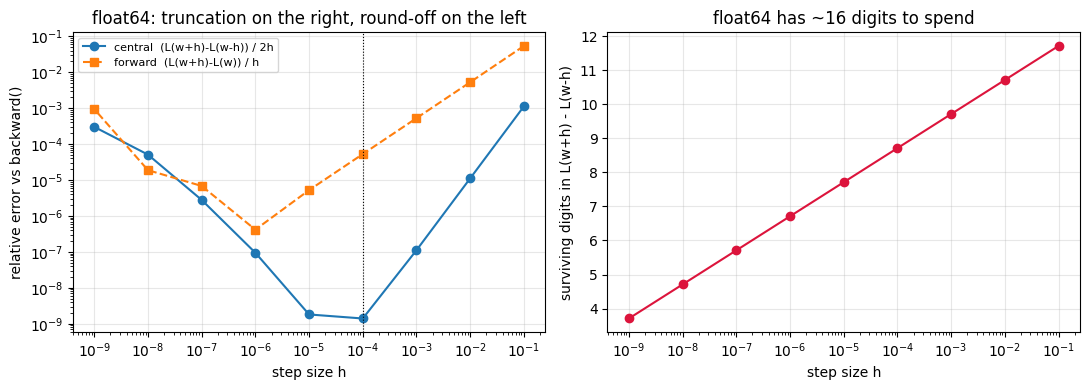

In [14]:
# ---------------------------------------------------------------------------------------
# Why there is a best h at all, and why the error goes back up on both sides of it.
# Left of the minimum, the estimator is honest but the subtraction has no digits left.
# Right of it, the subtraction is clean but the estimator is measuring a chord, not a
# tangent.  The plot is the U every numerical-differentiation textbook draws; this one is
# measured on a transformer.
# ---------------------------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog([s["h"] for s in sweep], [max(s["rel_central"], 1e-18) for s in sweep],
             "o-", label="central  (L(w+h)-L(w-h)) / 2h")
ax[0].loglog([s["h"] for s in sweep], [max(s["rel_forward"], 1e-18) for s in sweep],
             "s--", label="forward  (L(w+h)-L(w)) / h")
ax[0].axvline(best["h"], color="k", lw=0.8, ls=":")
ax[0].set_xlabel("step size h"); ax[0].set_ylabel("relative error vs backward()")
ax[0].set_title("float64: truncation on the right, round-off on the left")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

# How many digits of L(w+h) - L(w-h) are actually signal.
sig = [max(0.0, math.log10(abs(s["l_plus"] - s["l_minus"]) / abs(l0.item())) + 16)
       for s in sweep]
ax[1].semilogx([s["h"] for s in sweep], sig, "o-", color="crimson")
ax[1].set_xlabel("step size h")
ax[1].set_ylabel("surviving digits in L(w+h) - L(w-h)")
ax[1].set_title("float64 has ~16 digits to spend")
ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "gradcheck.png"), dpi=140)
show(fig)

In [15]:
# ---------------------------------------------------------------------------------------
# The same check in float32, which is what training actually runs in.  Nothing is wrong
# here: the gradient is the same gradient.  The difference is that the *measurement* has
# only ~7 digits to work with, so it can never confirm more than a few of them.  This is
# the distinction worth having: a failed finite-difference check is a statement about the
# arithmetic of the check before it is a statement about backward().
# ---------------------------------------------------------------------------------------
torch.manual_seed(SEED)
fd32 = GPT(cfg).float()
fd32.eval()
fd32.zero_grad(set_to_none=True)
_, l32 = fd32(x_fd, y_fd)
l32.backward()
ag32 = dict(fd32.named_parameters())[PARAM].grad[INDEX].item()
w032 = dict(fd32.named_parameters())[PARAM].data[INDEX].item()


def fd_loss32(w):
    p = dict(fd32.named_parameters())[PARAM]
    old = p.data[INDEX].item()
    p.data[INDEX] = w
    with torch.no_grad():
        _, l = fd32(x_fd, y_fd)
    p.data[INDEX] = old
    return l.item()


sweep32 = []
for h in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    c = (fd_loss32(w032 + h) - fd_loss32(w032 - h)) / (2 * h)
    sweep32.append(dict(h=h, central=c, digits=digits_agreeing(c, ag32),
                        rel=abs(c - ag32) / abs(ag32)))
best32 = max(sweep32, key=lambda s: s["digits"])

rule("The same check in float32")
print(f"{'h':>8} {'central diff':>16} {'backward()':>16} {'digits':>8}")
print("-" * 92)
for s in sweep32:
    print(f"{s['h']:>8.0e} {s['central']:>16.8f} {ag32:>16.8f} {s['digits']:>8.1f}")
print(f"\nfloat64 confirmed {best['digits']:.1f} digits; float32 confirms "
      f"{best32['digits']:.1f}.")
print("Same gradient, worse ruler.  The fp32 and fp64 gradients themselves agree to "
      f"{digits_agreeing(ag32, autograd_grad):.1f} digits.")
record("fd32_best_digits", round(best32["digits"], 1))
record("fd32_best_h", best32["h"])
record("fd32_vs_fd64_digits", round(digits_agreeing(ag32, autograd_grad), 1))


The same check in float32   [t+0m07s]
       h     central diff       backward()   digits
--------------------------------------------------------------------------------------------
   1e-01      -0.00277042      -0.00276673      2.9
   1e-02      -0.00281334      -0.00276673      1.8
   1e-03      -0.00333786      -0.00276673      0.7
   1e-04       0.00000000      -0.00276673     -0.0
   1e-05       0.00000000      -0.00276673     -0.0

float64 confirmed 8.9 digits; float32 confirms 2.9.
Same gradient, worse ruler.  The fp32 and fp64 gradients themselves agree to 5.9 digits.


5.9

In [16]:
# ---------------------------------------------------------------------------------------
# One weight could be luck.  Ten weights, one from every distinct kind of parameter in the
# model, at the best step size found above.
# ---------------------------------------------------------------------------------------
CHECKS = [
    ("transformer.wte.weight", (int(x_fd[0, 0]), 3)),        # an embedding row that is used
    ("transformer.wpe.weight", (0, 5)),
    ("transformer.h.0.ln_1.weight", (7,)),
    ("transformer.h.0.ln_1.bias", (7,)),
    ("transformer.h.0.attn.c_attn.weight", (0, 0)),
    ("transformer.h.0.attn.c_attn.bias", (11,)),
    ("transformer.h.0.attn.c_proj.weight", (2, 2)),
    ("transformer.h.0.mlp.c_proj.weight", (3, 9)),
    ("transformer.h.3.mlp.c_fc.weight", (1, 1)),
    ("transformer.ln_f.weight", (4,)),
]
h_star = best["h"]
params = dict(fd_model.named_parameters())
rows = []
for name, idx in CHECKS:
    p = params[name]
    old = p.data[idx].item()
    p.data[idx] = old + h_star
    with torch.no_grad():
        _, lp = fd_model(x_fd, y_fd)
    p.data[idx] = old - h_star
    with torch.no_grad():
        _, lm = fd_model(x_fd, y_fd)
    p.data[idx] = old
    fd = (lp.item() - lm.item()) / (2 * h_star)
    ag = p.grad[idx].item()
    rows.append(dict(name=name, index=list(idx), fd=fd, autograd=ag,
                     digits=digits_agreeing(fd, ag) if ag != 0 else float("nan"),
                     absdiff=abs(fd - ag)))

rule(f"Ten more gradients at h = {h_star:.0e}")
print(f"{'parameter':<38} {'finite difference':>20} {'backward()':>20} {'digits':>8}")
print("-" * 92)
for r in rows:
    print(f"{r['name'] + str(r['index']):<38} {r['fd']:>20.12f} {r['autograd']:>20.12f} "
          f"{r['digits']:>8.1f}")
worst = min(rows, key=lambda r: r["digits"])
print(f"\nworst agreement: {worst['name']}{worst['index']} at {worst['digits']:.1f} digits "
      f"(|difference| = {worst['absdiff']:.2e})")
record("fd_multi", [{k: v for k, v in r.items()} for r in rows])
record("fd_multi_worst_digits", round(worst["digits"], 1))
record("fd_multi_worst_name", worst["name"])


Ten more gradients at h = 1e-04   [t+0m08s]
parameter                                 finite difference           backward()   digits
--------------------------------------------------------------------------------------------
transformer.wte.weight[416, 3]               0.027524781183       0.027524782140      7.5
transformer.wpe.weight[0, 5]                 0.011088222172       0.011088223013      7.1
transformer.h.0.ln_1.weight[7]               0.000379957434       0.000379957440      7.8
transformer.h.0.ln_1.bias[7]                -0.007093144543      -0.007093144542     10.3
transformer.h.0.attn.c_attn.weight[0, 0]      -0.000259803370      -0.000259803370      9.1
transformer.h.0.attn.c_attn.bias[11]        -0.000341102329      -0.000341102322      7.7
transformer.h.0.attn.c_proj.weight[2, 2]      -0.014191744864      -0.014191744782      8.2
transformer.h.0.mlp.c_proj.weight[3, 9]      -0.026819933590      -0.026819933723      8.3
transformer.h.3.mlp.c_fc.weight[1, 1]        0.

'transformer.wpe.weight'

In [17]:
# ---------------------------------------------------------------------------------------
# The whole gradient vector at once.  Pick a random direction u, and compare the measured
# directional derivative with g . u.  Ten weights is ten scalars; this is one number that
# every one of the 16 million entries contributes to, so a sign error or a missing term
# anywhere in the model would show up here.
# ---------------------------------------------------------------------------------------
gen64 = torch.Generator().manual_seed(7)
plist = [p for p in fd_model.parameters()]
u = [torch.randn(p.shape, generator=gen64, dtype=torch.float64) for p in plist]
unorm = math.sqrt(sum((ui * ui).sum().item() for ui in u))
u = [ui / unorm for ui in u]
g_dot_u = sum((p.grad * ui).sum().item() for p, ui in zip(plist, u))

eps = 1e-6
saved = [p.data.clone() for p in plist]
for p, ui in zip(plist, u):
    p.data.add_(ui, alpha=eps)
with torch.no_grad():
    _, lp = fd_model(x_fd, y_fd)
for p, s in zip(plist, saved):
    p.data.copy_(s)
for p, ui in zip(plist, u):
    p.data.add_(ui, alpha=-eps)
with torch.no_grad():
    _, lm = fd_model(x_fd, y_fd)
for p, s in zip(plist, saved):
    p.data.copy_(s)

dir_fd = (lp.item() - lm.item()) / (2 * eps)

rule("The entire gradient at once: a directional derivative")
print(f"random unit direction u over all {sum(p.numel() for p in plist):,} parameters")
print(f"measured  (L(t+eu) - L(t-eu)) / 2e = {dir_fd:.15f}")
print(f"reported   g . u                   = {g_dot_u:.15f}")
print(f"agree to                           = {digits_agreeing(dir_fd, g_dot_u):.1f} digits")
record("dirderiv_fd", dir_fd)
record("dirderiv_dot", g_dot_u)
record("dirderiv_digits", round(digits_agreeing(dir_fd, g_dot_u), 1))


The entire gradient at once: a directional derivative   [t+0m08s]
random unit direction u over all 16,058,112 parameters
measured  (L(t+eu) - L(t-eu)) / 2e = -0.005321614260367
reported   g . u                   = -0.005321614514971
agree to                           = 7.3 digits


7.3

In [18]:
# ---------------------------------------------------------------------------------------
# "...and if they do not agree, you have found something worth understanding."
#
# Here is the most common something.  Turn dropout on -- change nothing else -- and the
# check collapses.  backward() is still exactly right; L is no longer a function of w
# alone, so the quantity the finite difference measures is not the quantity backward()
# computes.  The tell is that repeating the *same* evaluation twice already disagrees.
# ---------------------------------------------------------------------------------------
drop_cfg = Config(dropout=0.1)
torch.manual_seed(SEED)
noisy = GPT(drop_cfg).double()
noisy.train()                              # dropout ACTIVE
noisy.zero_grad(set_to_none=True)
_, ln = noisy(x_fd, y_fd)
ln.backward()
ag_noisy = dict(noisy.named_parameters())[PARAM].grad[INDEX].item()
w_noisy = dict(noisy.named_parameters())[PARAM].data[INDEX].item()

reps = [fd_loss(noisy) for _ in range(4)]
lp_n, lm_n = fd_loss(noisy, w_noisy + h_star), fd_loss(noisy, w_noisy - h_star)
fd_noisy = (lp_n - lm_n) / (2 * h_star)

rule("What a failing check looks like, and what it means")
print("the same loss, evaluated four times at the same weights, with dropout on:")
for r in reps:
    print(f"    {r:.17g}")
print(f"spread across identical evaluations : {max(reps) - min(reps):.3e}")
print(f"the nudge only has to move the loss : ~{abs(ag_noisy) * h_star:.3e}")
print(f"\nfinite difference : {fd_noisy:.6f}")
print(f"backward()        : {ag_noisy:.6f}")
print(f"agreement         : {digits_agreeing(fd_noisy, ag_noisy):.1f} digits  <- the check fails")
print("\nThe noise floor is larger than the signal being measured, and it is larger for a")
print("reason: L(w) is not a function at all here, it is a distribution.  Before blaming")
print("backward(), evaluate the loss twice without touching anything.  If those two numbers")
print("differ, the finite-difference check cannot be run yet.")
record("noisy_spread", max(reps) - min(reps))
record("noisy_signal", abs(ag_noisy) * h_star)
record("noisy_fd", fd_noisy)
record("noisy_autograd", ag_noisy)
record("noisy_digits", round(digits_agreeing(fd_noisy, ag_noisy), 1))


What a failing check looks like, and what it means   [t+0m09s]
the same loss, evaluated four times at the same weights, with dropout on:
    10.852335674749181
    10.790672167884086
    10.858369864233902
    10.79245998259243
spread across identical evaluations : 6.770e-02
the nudge only has to move the loss : ~3.187e-07

finite difference : -78.989978
backward()        : -0.003187
agreement         : -4.4 digits  <- the check fails

The noise floor is larger than the signal being measured, and it is larger for a
reason: L(w) is not a function at all here, it is a distribution.  Before blaming
backward(), evaluate the loss twice without touching anything.  If those two numbers
differ, the finite-difference check cannot be run yet.


-4.4

In [19]:
EXPLICIT_ATTENTION = False                # back to the fused kernel for everything below

## 3. Breaking gradient accumulation on purpose

Accumulation exists because the batch you want does not fit in the GPU you have. You run
`G` micro-batches, add their gradients up, and step once. The only question is what
weight each micro-batch gets in that sum.

* **Correct:** every *token* counts once. Micro-batch `i` contributing `n_i` tokens gets
  weight `n_i / N`, where `N = sum(n_i)`. This is the gradient of the mean loss over the
  whole batch, which is the objective you think you are optimising.
* **Broken:** every *micro-batch* counts once — the average of the averages, weight `1/G`.

Both weight sets sum to 1, so this is not a learning-rate bug in disguise. When the `n_i`
are equal the two are *identical*, which is why the bug survived in every major framework
until 2024: with fixed-length packing you never see it. It only appears when micro-batches
have different numbers of contributing tokens — masked padding, masked prompts, ragged
documents.

The lengths here are not synthetic. Tiny Shakespeare split at blank lines gives 7,222
documents whose token lengths run from a handful to 858, and short documents are a
*different kind of text* from long ones (speaker headings and one-line exchanges versus
speeches). So the mis-weighting is a real bias, not extra noise: it systematically
over-weights one register of the corpus.

In [20]:
# ---------------------------------------------------------------------------------------
# Documents, and the two pools whose lengths differ.
# ---------------------------------------------------------------------------------------
raw_docs = [d for d in text.split("\n\n") if d.strip()]
doc_ids = [enc.encode(d) for d in raw_docs]
doc_len = np.array([len(d) for d in doc_ids])

n_doc_train = int(0.9 * len(doc_ids))
train_docs = doc_ids[:n_doc_train]
val_docs = doc_ids[n_doc_train:]

SHORT_MAX, LONG_MIN = 32, 64
pool_short = [d for d in train_docs if len(d) < SHORT_MAX]
pool_long = [d for d in train_docs if len(d) >= LONG_MIN]

rule("Documents, and why their lengths matter")
print(f"documents            : {len(doc_ids):,}  (train {len(train_docs):,} / "
      f"val {len(val_docs):,})")
print(f"token length         : median {int(np.median(doc_len))}, "
      f"p90 {int(np.percentile(doc_len, 90))}, max {doc_len.max()}")
print(f"short pool (<{SHORT_MAX} tok) : {len(pool_short):,} documents, "
      f"mean length {np.mean([len(d) for d in pool_short]):.1f}")
print(f"long  pool (>={LONG_MIN} tok): {len(pool_long):,} documents, "
      f"mean length {np.mean([len(d) for d in pool_long]):.1f}")
print(f"\nfirst short document : {raw_docs[[i for i, d in enumerate(train_docs) if len(d) < SHORT_MAX][0]]!r}")
_li = [i for i, d in enumerate(train_docs) if len(d) >= LONG_MIN][0]
print(f"first long document  : {raw_docs[_li][:90]!r}...")
record("n_docs", len(doc_ids))
record("doc_len_median", int(np.median(doc_len)))
record("doc_len_max", int(doc_len.max()))
record("n_pool_short", len(pool_short))
record("n_pool_long", len(pool_long))
record("pool_short_mean_len", round(float(np.mean([len(d) for d in pool_short])), 1))
record("pool_long_mean_len", round(float(np.mean([len(d) for d in pool_long])), 1))


Documents, and why their lengths matter   [t+0m09s]
documents            : 7,222  (train 6,499 / val 723)
token length         : median 26, p90 98, max 858
short pool (<32 tok) : 3,823 documents, mean length 17.8
long  pool (>=64 tok): 1,297 documents, mean length 130.3

first short document : 'First Citizen:\nBefore we proceed any further, hear me speak.'
first long document  : 'First Citizen:\nWe are accounted poor citizens, the patricians good.\nWhat authority surfeit'...


130.3

In [21]:
# ---------------------------------------------------------------------------------------
# One micro-batch: B rows, one document per row, padded to T.  Padding is masked out of the
# target, so n_i -- the number of positions that actually contribute -- varies by row.
# ---------------------------------------------------------------------------------------
PAD = enc.eot_token
B_MICRO, T_MICRO, G_ACC = 4, cfg.block_size, 4


def pack(docs, rng, B=B_MICRO, T=T_MICRO, dev=None):
    """A [B,T] input / [B,T] target pair from B documents, padded and masked."""
    x = np.full((B, T), PAD, dtype=np.int64)
    y = np.full((B, T), IGNORE, dtype=np.int64)
    for r in range(B):
        d = docs[rng.integers(len(docs))][:T + 1]
        if len(d) < 2:
            d = d + [PAD]
        x[r, :len(d) - 1] = d[:-1]
        y[r, :len(d) - 1] = d[1:]
    dev = dev or device
    return (torch.from_numpy(x).to(dev), torch.from_numpy(y).to(dev),
            int((y != IGNORE).sum()))


# The step layout: two micro-batches of long documents, two of short ones.  This is a shard
# of long examples followed by a shard of short ones -- ordinary, and enough to break it.
STEP_POOLS = ["long", "long", "short", "short"]


def make_step(rng):
    return [pack(pool_long if p == "long" else pool_short, rng) for p in STEP_POOLS]


rng0 = np.random.default_rng(SEED)
demo = make_step(rng0)
ns = [n for _, _, n in demo]
N_tot = sum(ns)
w_correct = [n / N_tot for n in ns]
w_broken = [1.0 / G_ACC] * G_ACC

rule("One step's four micro-batches")
print(f"{'micro-batch':<14} {'pool':<8} {'tokens n_i':>12} {'correct n_i/N':>15} "
      f"{'broken 1/G':>12} {'ratio':>8}")
print("-" * 92)
for i, (p, n) in enumerate(zip(STEP_POOLS, ns)):
    print(f"{i:<14} {p:<8} {n:>12,} {w_correct[i]:>15.4f} {w_broken[i]:>12.4f} "
          f"{w_broken[i] / w_correct[i]:>7.2f}x")
print(f"{'total':<14} {'':<8} {N_tot:>12,} {sum(w_correct):>15.4f} {sum(w_broken):>12.4f}")
print(f"\nBoth columns sum to 1: the broken rule is not a change of learning rate.")
print(f"It is a change of *which examples the batch is made of* -- short documents are")
print(f"weighted {max(w_broken[i] / w_correct[i] for i in range(G_ACC)):.2f}x too heavily, "
      f"long ones {min(w_broken[i] / w_correct[i] for i in range(G_ACC)):.2f}x too lightly.")
record("accum_ns", ns)
record("accum_N", N_tot)
record("accum_w_correct", [round(w, 4) for w in w_correct])
record("accum_w_broken", w_broken)
record("accum_max_overweight", round(max(w_broken[i] / w_correct[i] for i in range(G_ACC)), 2))
record("accum_min_underweight", round(min(w_broken[i] / w_correct[i] for i in range(G_ACC)), 2))


One step's four micro-batches   [t+0m09s]
micro-batch    pool       tokens n_i   correct n_i/N   broken 1/G    ratio
--------------------------------------------------------------------------------------------
0              long              421          0.4021       0.2500    0.62x
1              long              490          0.4680       0.2500    0.53x
2              short              71          0.0678       0.2500    3.69x
3              short              65          0.0621       0.2500    4.03x
total                          1,047          1.0000       1.0000

Both columns sum to 1: the broken rule is not a change of learning rate.
It is a change of *which examples the batch is made of* -- short documents are
weighted 4.03x too heavily, long ones 0.53x too lightly.


0.53

In [22]:
# ---------------------------------------------------------------------------------------
# The two accumulation rules, side by side.  Nothing differs but the scalar each
# micro-batch's loss is multiplied by before backward().
# ---------------------------------------------------------------------------------------
def accumulate(model, micros, rule_name):
    """Returns (reported loss, total contributing tokens).  Gradients land in .grad."""
    model.zero_grad(set_to_none=True)
    N = sum(n for _, _, n in micros)
    G = len(micros)
    reported = 0.0
    for x, y, n in micros:
        _, s = model(x, y, reduction="sum")          # sum of per-token losses
        if rule_name == "correct":
            scaled = s / N                            # every token counts once
        else:
            scaled = (s / max(n, 1)) / G              # the average of the averages
        scaled.backward()
        reported += scaled.item()
    return reported, N


def flat_grad(model):
    return torch.cat([p.grad.reshape(-1) for p in model.parameters()])


torch.manual_seed(SEED)
probe = GPT(cfg).to(device)
probe.train()

_, _ = accumulate(probe, demo, "correct")
g_correct = flat_grad(probe).clone()
_, _ = accumulate(probe, demo, "broken")
g_broken = flat_grad(probe).clone()

cos = F.cosine_similarity(g_correct, g_broken, dim=0).item()
norm_ratio = (g_broken.norm() / g_correct.norm()).item()
rel_l2 = ((g_broken - g_correct).norm() / g_correct.norm()).item()
angle = math.degrees(math.acos(min(1.0, max(-1.0, cos))))

rule("The two gradients, at the same weights, from the same four micro-batches")
print(f"cosine similarity          : {cos:.6f}   ({angle:.2f} degrees apart)")
print(f"||broken|| / ||correct||   : {norm_ratio:.4f}")
print(f"||broken - correct|| / ||correct|| : {rel_l2:.4f}")
print(f"\nThe norms are within {abs(1 - norm_ratio) * 100:.1f}% of each other, so a learning-rate")
print("adjustment cannot repair this.  The vectors point in different directions.")
record("accum_cos", cos)
record("accum_angle_deg", round(angle, 2))
record("accum_norm_ratio", round(norm_ratio, 4))
record("accum_rel_l2", round(rel_l2, 4))


The two gradients, at the same weights, from the same four micro-batches   [t+0m10s]
cosine similarity          : 0.874579   (29.00 degrees apart)
||broken|| / ||correct||   : 1.0796
||broken - correct|| / ||correct|| : 0.5264

The norms are within 8.0% of each other, so a learning-rate
adjustment cannot repair this.  The vectors point in different directions.


0.5264

In [23]:
# ---------------------------------------------------------------------------------------
# The control that explains why nobody noticed.  Same code, same model, but every
# micro-batch now contributes the same number of tokens.
# ---------------------------------------------------------------------------------------
def pack_fixed(docs, rng, B=B_MICRO, T=T_MICRO):
    """Every row full: documents concatenated and cut to exactly T, nothing masked."""
    x = np.zeros((B, T), dtype=np.int64)
    y = np.zeros((B, T), dtype=np.int64)
    for r in range(B):
        buf = []
        while len(buf) < T + 1:
            buf.extend(docs[rng.integers(len(docs))])
        x[r], y[r] = buf[:T], buf[1:T + 1]
    return (torch.from_numpy(x).to(device), torch.from_numpy(y).to(device), B * T)


rng_c = np.random.default_rng(SEED)
equal = [pack_fixed(train_docs, rng_c) for _ in range(G_ACC)]
_, _ = accumulate(probe, equal, "correct")
gc_eq = flat_grad(probe).clone()
_, _ = accumulate(probe, equal, "broken")
gb_eq = flat_grad(probe).clone()
eq_cos = F.cosine_similarity(gc_eq, gb_eq, dim=0).item()
eq_maxdiff = (gc_eq - gb_eq).abs().max().item()

rule("The definition of correct: accumulating must equal not accumulating")
big_x = torch.cat([x for x, _, _ in demo])
big_y = torch.cat([y for _, y, _ in demo])
probe.zero_grad(set_to_none=True)
_, one_shot = probe(big_x, big_y, reduction="mean")     # the whole batch in one go
one_shot.backward()
g_oneshot = flat_grad(probe).clone()
print(f"all {big_x.shape[0]} rows in a single forward : loss {one_shot.item():.6f}")
print(f"max |correct-rule grad - one-shot grad| : "
      f"{(g_correct - g_oneshot).abs().max().item():.3e}")
print(f"max |broken-rule  grad - one-shot grad| : "
      f"{(g_broken - g_oneshot).abs().max().item():.3e}")
print("\nThe correct rule is not a better approximation.  It is the same number.")
record("accum_oneshot_maxdiff_correct", (g_correct - g_oneshot).abs().max().item())
record("accum_oneshot_maxdiff_broken", (g_broken - g_oneshot).abs().max().item())
assert (g_correct - g_oneshot).abs().max().item() < 1e-6


The definition of correct: accumulating must equal not accumulating   [t+0m10s]
all 16 rows in a single forward : loss 10.880198
max |correct-rule grad - one-shot grad| : 1.192e-07
max |broken-rule  grad - one-shot grad| : 1.114e-01

The correct rule is not a better approximation.  It is the same number.


In [24]:
rule("Control: equal-length micro-batches")
print(f"tokens per micro-batch : {[n for _, _, n in equal]}")
print(f"cosine similarity      : {eq_cos:.12f}")
print(f"max |difference|       : {eq_maxdiff:.3e}")
print("\nIdentical to the last bit.  The bug is invisible under fixed-length packing, which")
print("is exactly how it survived in production frameworks for years.")
record("accum_equal_cos", eq_cos)
record("accum_equal_maxdiff", eq_maxdiff)
assert eq_cos > 1 - 1e-6


Control: equal-length micro-batches   [t+0m10s]
tokens per micro-batch : [512, 512, 512, 512]
cosine similarity      : 1.000000000000
max |difference|       : 0.000e+00

Identical to the last bit.  The bug is invisible under fixed-length packing, which
is exactly how it survived in production frameworks for years.


In [25]:
# ---------------------------------------------------------------------------------------
# Now train both.  Identical initialisation, identical data, identical seeds; the *only*
# difference is the scalar in accumulate().  Both are then judged by the same ruler: the
# correctly token-weighted loss on held-out documents.
# ---------------------------------------------------------------------------------------
ACC_STEPS, EVAL_EVERY = 300, 20
LR = 6e-4
del g_correct, g_broken, gc_eq, gb_eq, g_oneshot, probe
torch.cuda.empty_cache() if device.type == "cuda" else None


def eval_docs(model, batches):
    """Correctly weighted loss: total loss over total contributing tokens."""
    model.eval()
    tot, ntot = 0.0, 0
    with torch.no_grad():
        for x, y, n in batches:
            _, s = model(x, y, reduction="sum")
            tot += s.item()
            ntot += n
    model.train()
    return tot / ntot


rng_ev = np.random.default_rng(999)
val_short = [d for d in val_docs if len(d) < SHORT_MAX]
val_long = [d for d in val_docs if len(d) >= LONG_MIN]
eval_batches = ([pack(val_docs, rng_ev) for _ in range(6)] +
                [pack(val_long, rng_ev) for _ in range(3)])
eval_short = [pack(val_short, rng_ev) for _ in range(5)]
eval_long = [pack(val_long, rng_ev) for _ in range(5)]


def train_arm(rule_name):
    torch.manual_seed(SEED)                       # identical init
    m = GPT(cfg).to(device)
    m.train()
    o = torch.optim.AdamW(m.parameters(), lr=LR, betas=(0.9, 0.95), weight_decay=0.1)
    rng = np.random.default_rng(4242)             # identical data stream
    hist = dict(step=[], reported=[], eval=[], eval_short=[], eval_long=[])
    for step in range(ACC_STEPS + 1):
        micros = make_step(rng)
        if step % EVAL_EVERY == 0:
            hist["step"].append(step)
            hist["eval"].append(eval_docs(m, eval_batches))
            hist["eval_short"].append(eval_docs(m, eval_short))
            hist["eval_long"].append(eval_docs(m, eval_long))
        rep, _ = accumulate(m, micros, rule_name)
        hist["reported"].append(rep)
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        o.step()
        o.zero_grad(set_to_none=True)
    return m, hist


t0 = time.time()
m_correct, h_correct = train_arm("correct")
m_broken, h_broken = train_arm("broken")
print(f"two {ACC_STEPS}-step runs in {time.time() - t0:.1f}s")

rule(f"After {ACC_STEPS} steps, judged by the same held-out, token-weighted loss")
print(f"{'':<26} {'correct rule':>14} {'broken rule':>14} {'gap':>10}")
print("-" * 92)
for label, key in [("held-out (all docs)", "eval"), ("held-out (short docs)", "eval_short"),
                   ("held-out (long docs)", "eval_long")]:
    a, b = h_correct[key][-1], h_broken[key][-1]
    print(f"{label:<26} {a:>14.4f} {b:>14.4f} {b - a:>+10.4f}")
print(f"{'its own reported loss':<26} {h_correct['reported'][-1]:>14.4f} "
      f"{h_broken['reported'][-1]:>14.4f}")
print("\n(the last row is the number each run prints to its own log -- not comparable")
print(" between the two, because the broken run is reporting a different quantity)")

record("accum_steps", ACC_STEPS)
record("accum_lr", LR)
record("accum_final_correct", h_correct["eval"][-1])
record("accum_final_broken", h_broken["eval"][-1])
record("accum_final_gap", h_broken["eval"][-1] - h_correct["eval"][-1])
record("accum_final_correct_short", h_correct["eval_short"][-1])
record("accum_final_broken_short", h_broken["eval_short"][-1])
record("accum_final_correct_long", h_correct["eval_long"][-1])
record("accum_final_broken_long", h_broken["eval_long"][-1])
record("accum_curve_steps", h_correct["step"])
record("accum_curve_correct", h_correct["eval"])
record("accum_curve_broken", h_broken["eval"])

two 300-step runs in 85.5s

After 300 steps, judged by the same held-out, token-weighted loss   [t+1m36s]
                             correct rule    broken rule        gap
--------------------------------------------------------------------------------------------
held-out (all docs)                5.4930         5.6149    +0.1219
held-out (short docs)              4.5083         4.6442    +0.1359
held-out (long docs)               5.5865         5.7270    +0.1405
its own reported loss              4.9830         4.5756

(the last row is the number each run prints to its own log -- not comparable
 between the two, because the broken run is reporting a different quantity)


[10.868399980772345,
 7.310487034544563,
 6.492295497439686,
 6.251322006726306,
 6.168651925604715,
 6.017813700674317,
 5.958603836437306,
 5.892760589195519,
 5.835162464201142,
 5.800331251883411,
 5.755214895403241,
 5.719860913634094,
 5.653153089524413,
 5.64072526702266,
 5.63184105890128,
 5.614897381525034]

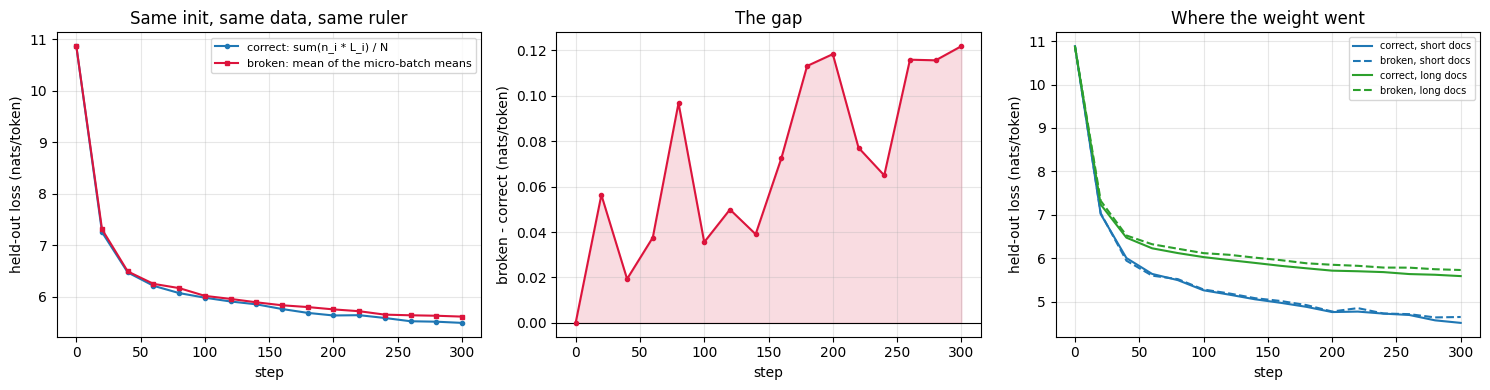

In [26]:
# ---------------------------------------------------------------------------------------
# Both curves on the same axes, which is the point of the exercise: the gap is a thing you
# look at, not a thing you are told about.
# ---------------------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(h_correct["step"], h_correct["eval"], "-o", ms=3, label="correct: sum(n_i * L_i) / N")
ax[0].plot(h_broken["step"], h_broken["eval"], "-s", ms=3, color="crimson",
           label="broken: mean of the micro-batch means")
ax[0].set_xlabel("step"); ax[0].set_ylabel("held-out loss (nats/token)")
ax[0].set_title("Same init, same data, same ruler")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

gap = [b - a for a, b in zip(h_correct["eval"], h_broken["eval"])]
ax[1].axhline(0, color="k", lw=0.8)
ax[1].plot(h_correct["step"], gap, "-o", ms=3, color="crimson")
ax[1].fill_between(h_correct["step"], 0, gap, color="crimson", alpha=0.15)
ax[1].set_xlabel("step"); ax[1].set_ylabel("broken - correct (nats/token)")
ax[1].set_title("The gap")
ax[1].grid(alpha=0.3)

ax[2].plot(h_correct["step"], h_correct["eval_short"], "-", color="C0",
           label="correct, short docs")
ax[2].plot(h_broken["step"], h_broken["eval_short"], "--", color="C0",
           label="broken, short docs")
ax[2].plot(h_correct["step"], h_correct["eval_long"], "-", color="C2",
           label="correct, long docs")
ax[2].plot(h_broken["step"], h_broken["eval_long"], "--", color="C2",
           label="broken, long docs")
ax[2].set_xlabel("step"); ax[2].set_ylabel("held-out loss (nats/token)")
ax[2].set_title("Where the weight went")
ax[2].legend(fontsize=7); ax[2].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "accumulation.png"), dpi=140)
show(fig)

## 4. The grad norm moves before the loss does

The loss at step `k` is measured on batch `k`, so it tells you about that batch. The grad
norm at step `k` tells you about the *update you are about to apply to every future batch*.
That asymmetry is the whole reason to log it: damage enters through the gradient and only
later shows up in the loss.

Making that observable needs one extra instrument. The training loss jumps around with the
batch, so a two-step trend change is invisible in it. Every run below therefore also
evaluates a **fixed probe batch** — the same tokens, every step, measured *before* the
update is applied. The probe is the loss curve you would actually watch; the reported
training loss is kept alongside to show why it is the worse instrument.

Order within a step, which is what makes "before" meaningful:

1. measure the probe with the weights entering step `k` → `probe[k]`
2. forward/backward on batch `k` → `loss[k]`, `gradnorm[k]`
3. apply the update

So a spike in `gradnorm[k]` cannot reach `probe[k]`. If the probe departs later, the norm
saw it first.

Four runs, and the negative results are reported alongside the positive one: a healthy run
at `lr=1.2e-3`, an aggressive one at `lr=5e-3` where instability is likelier, and a pair in
which a corrupted data shard is injected at a known step — one clipped, one not.

In [27]:
# ---------------------------------------------------------------------------------------
# The instrumented loop.  Clipping is optional because the point of section 4 is what
# happens when you do not clip.
# ---------------------------------------------------------------------------------------
B_LOG, T_LOG = 8, cfg.block_size
LOG_STEPS = 600
LOG_LR = 1.2e-3


def global_grad_norm(model):
    """The same quantity clip_grad_norm_ computes: the L2 norm of all gradients as one vector."""
    return torch.sqrt(sum((p.grad.detach() ** 2).sum() for p in model.parameters()
                          if p.grad is not None)).item()


probe_gen = torch.Generator().manual_seed(31337)
probe_x, probe_y = get_batch("val", 16, T_LOG, generator=probe_gen)


def probe_loss(model):
    model.eval()
    with torch.no_grad():
        _, l = model(probe_x, probe_y)
    model.train()
    return l.item()


def run_logged(steps=LOG_STEPS, clip=None, corrupt_at=None, corrupt_len=3,
               corrupt_frac=0.25, seed=SEED, lr=LOG_LR):
    """One training run, logging loss and grad norm at every step.

    corrupt_at: inject a shard in which `corrupt_frac` of the token ids have been replaced
    with uniform random ids -- a corrupted data shard, the thing that actually happens.
    """
    torch.manual_seed(seed)
    m = GPT(cfg).to(device)
    m.train()
    o = torch.optim.AdamW(m.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)
    g = torch.Generator().manual_seed(seed + 1)
    gc = torch.Generator(device=device).manual_seed(seed + 2)
    log = dict(step=[], loss=[], gnorm=[], probe=[], corrupt=[])
    for k in range(steps):
        log["probe"].append(probe_loss(m))                     # 1. before the update
        x, y = get_batch("train", B_LOG, T_LOG, generator=g)
        bad = corrupt_at is not None and corrupt_at <= k < corrupt_at + corrupt_len
        if bad:
            mask = torch.rand(y.shape, generator=gc, device=device) < corrupt_frac
            noise = torch.randint(0, cfg.vocab_size, y.shape, generator=gc, device=device)
            y = torch.where(mask, noise, y)
        m.zero_grad(set_to_none=True)
        _, l = m(x, y)                                          # 2. this step's gradient
        l.backward()
        gn = global_grad_norm(m)
        if clip is not None:
            torch.nn.utils.clip_grad_norm_(m.parameters(), clip)
        o.step()                                                # 3. apply
        log["step"].append(k)
        log["loss"].append(l.item())
        log["gnorm"].append(gn)
        log["corrupt"].append(bool(bad))
    return m, log


t0 = time.time()
_, log_nat = run_logged()
print(f"natural run: {LOG_STEPS} steps in {time.time() - t0:.1f}s, "
      f"no clipping, lr={LOG_LR}")
print(f"final probe loss {log_nat['probe'][-1]:.4f}, "
      f"grad norm range {min(log_nat['gnorm']):.3f} .. {max(log_nat['gnorm']):.3f}")
record("log_steps", LOG_STEPS)
record("log_lr", LOG_LR)
record("log_gnorm_min", min(log_nat["gnorm"]))
record("log_gnorm_max", max(log_nat["gnorm"]))

natural run: 600 steps in 63.7s, no clipping, lr=0.0012
final probe loss 5.4032, grad norm range 0.584 .. 753.012


753.0119018554688

In [28]:
# ---------------------------------------------------------------------------------------
# A second run at an aggressive learning rate.  A healthy run may simply have nothing to
# find; if the phenomenon is real it should be easier to see where the optimiser is being
# pushed harder, so the search is run on both and both answers are reported.
# ---------------------------------------------------------------------------------------
HOT_LR = 5e-3
t0 = time.time()
_, log_hot = run_logged(lr=HOT_LR)
print(f"aggressive run: {LOG_STEPS} steps at lr={HOT_LR} in {time.time() - t0:.1f}s, "
      f"no clipping")
print(f"final probe loss {log_hot['probe'][-1]:.4f} "
      f"(vs {log_nat['probe'][-1]:.4f} at lr={LOG_LR}), "
      f"grad norm up to {max(log_hot['gnorm']):.2f}")
record("hot_lr", HOT_LR)
record("hot_final_probe", log_hot["probe"][-1])
record("nat_final_probe", log_nat["probe"][-1])
record("hot_gnorm_max", round(max(log_hot["gnorm"]), 3))

aggressive run: 600 steps at lr=0.005 in 63.8s, no clipping
final probe loss 5.6026 (vs 5.4032 at lr=0.0012), grad norm up to 11.13


11.129

In [29]:
# ---------------------------------------------------------------------------------------
# Does the norm lead the loss *in general*?  One number: the lag at which changes in grad
# norm correlate best with changes in the probe loss.  Positive lag = the norm moved first.
# ---------------------------------------------------------------------------------------
def lagged_corr(a, b, lags):
    """corr(a[t], b[t+lag]) over the valid overlap, for each lag."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    out = []
    for L in lags:
        if L >= 0:
            u, v = a[:len(a) - L], b[L:]
        else:
            u, v = a[-L:], b[:len(b) + L]
        u, v = u - u.mean(), v - v.mean()
        d = (np.linalg.norm(u) * np.linalg.norm(v))
        out.append(float((u * v).sum() / d) if d > 0 else 0.0)
    return out


WARM = 50                                    # skip the initial collapse from ln(V)
lags = list(range(-10, 11))


def corr_profile(log):
    dg = np.diff(np.asarray(log["gnorm"])[WARM:])
    dp = np.diff(np.asarray(log["probe"])[WARM:])
    return lagged_corr(dg, dp, lags)


cc_nat, cc_hot = corr_profile(log_nat), corr_profile(log_hot)
best_lag_nat = lags[int(np.argmax(cc_nat))]
best_lag_hot = lags[int(np.argmax(cc_hot))]

rule("Cross-correlation: change in grad norm vs change in probe loss")
print(f"{'lag':>5} {'lr=' + str(LOG_LR):>10} {'lr=' + str(HOT_LR):>10}    "
      f"(lag > 0 means the grad norm moved first)")
for L, a, b in zip(lags, cc_nat, cc_hot):
    print(f"{L:>5} {a:>10.3f} {b:>10.3f}    {'#' * int(abs(b) * 50)}")
print(f"\npeak at lag {best_lag_nat:+d} (corr {max(cc_nat):.3f}) and lag "
      f"{best_lag_hot:+d} (corr {max(cc_hot):.3f})")
print("\nSo, honestly: across a whole run there is no lead to speak of.  Both peaks sit at")
print("lag 0 or below and the correlations are weak.  That is not a failed measurement, it")
print("is the answer to the general question -- on an ordinary step the grad norm and the")
print("loss are both just reporting the current batch, so of course they move together.")
print("The lead is not a property of every step.  It is a property of the steps where")
print("something is actually going wrong, and those have to be found individually.")
record("lag_best_nat", int(best_lag_nat))
record("lag_best_nat_corr", round(float(max(cc_nat)), 3))
record("lag_best_hot", int(best_lag_hot))
record("lag_best_hot_corr", round(float(max(cc_hot)), 3))
record("lag_values", lags)
record("lag_corr_nat", [round(c, 3) for c in cc_nat])
record("lag_corr_hot", [round(c, 3) for c in cc_hot])


Cross-correlation: change in grad norm vs change in probe loss   [t+3m44s]
  lag  lr=0.0012   lr=0.005    (lag > 0 means the grad norm moved first)
  -10      0.010      0.023    #
   -9      0.018      0.040    ##
   -8     -0.007     -0.035    #
   -7     -0.033      0.004    
   -6      0.006     -0.037    #
   -5      0.009     -0.009    
   -4     -0.010      0.004    
   -3      0.029      0.051    ##
   -2     -0.021     -0.054    ##
   -1     -0.052     -0.009    
    0      0.142      0.165    ########
    1     -0.075     -0.080    ####
    2     -0.025     -0.047    ##
    3     -0.028     -0.004    
    4      0.028      0.020    #
    5      0.014      0.001    
    6     -0.003     -0.057    ##
    7      0.010      0.032    #
    8     -0.002      0.061    ###
    9     -0.027     -0.011    
   10      0.025     -0.062    ###

peak at lag +0 (corr 0.142) and lag +0 (corr 0.165)

So, honestly: across a whole run there is no lead to speak of.  Both peaks sit at
lag 0 or b

[0.023,
 0.04,
 -0.035,
 0.004,
 -0.037,
 -0.009,
 0.004,
 0.051,
 -0.054,
 -0.009,
 0.165,
 -0.08,
 -0.047,
 -0.004,
 0.02,
 0.001,
 -0.057,
 0.032,
 0.061,
 -0.011,
 -0.062]

In [30]:
# ---------------------------------------------------------------------------------------
# So look for individual steps.  A trailing window of 25 steps gives a median and a MAD;
# "moved" means a robust z-score above a threshold.  The step wanted is one where the norm
# moved, the probe had not yet, and the probe moved afterwards.
# ---------------------------------------------------------------------------------------
def robust_z(series, k, window=25):
    """How unusual series[k] is against the `window` steps before it."""
    hist = np.asarray(series[max(0, k - window):k], dtype=float)
    if len(hist) < 5:
        return 0.0, 0.0, 0.0
    med = float(np.median(hist))
    mad = float(np.median(np.abs(hist - med))) * 1.4826
    mad = max(mad, 1e-9)
    return (series[k] - med) / mad, med, mad


def find_lead_events(log, z_g=4.0, z_quiet=1.5, z_after=3.0, horizon=8, window=25,
                     start=WARM):
    events = []
    g, p = log["gnorm"], log["probe"]
    for k in range(start, len(g) - horizon - 1):
        zg, gmed, _ = robust_z(g, k, window)
        zp, pmed, pmad = robust_z(p, k, window)
        if zg < z_g or abs(zp) > z_quiet:
            continue
        after = [((p[k + d] - pmed) / max(pmad, 1e-9), d) for d in range(1, horizon + 1)]
        hit = [(z, d) for z, d in after if z > z_after]
        if hit:
            z_peak, d_peak = max(hit)
            events.append(dict(step=k, z_gnorm=zg, gnorm=g[k], gnorm_median=gmed,
                               z_probe=zp, probe=p[k], probe_median=pmed,
                               lead=min(d for _, d in hit), z_after=z_peak,
                               probe_after=p[k + min(d for _, d in hit)]))
    return events


# The thresholds were not chosen after looking at the answer, so here is the whole grid.
rule("How many such steps exist, at every threshold I might have picked")
print(f"{'z(grad norm) >':>15} {'z(loss later) >':>17} {'lr=' + str(LOG_LR):>12} "
      f"{'lr=' + str(HOT_LR):>12}")
print("-" * 92)
grid = []
for zg in (2.0, 3.0, 4.0, 5.0):
    for za in (2.0, 3.0):
        a = len(find_lead_events(log_nat, z_g=zg, z_after=za))
        b = len(find_lead_events(log_hot, z_g=zg, z_after=za))
        grid.append(dict(z_g=zg, z_after=za, natural=a, hot=b))
        print(f"{zg:>15.1f} {za:>17.1f} {a:>12} {b:>12}")
record("lead_grid", grid)

events_nat = find_lead_events(log_nat)
events_hot = find_lead_events(log_hot)
print(f"\nAt the threshold I would defend (4 sigma on the norm, quiet loss, 3 sigma later):")
print(f"  lr={LOG_LR}: {len(events_nat)} steps out of {LOG_STEPS - WARM}")
print(f"  lr={HOT_LR}: {len(events_hot)} steps out of {LOG_STEPS - WARM}")
record("lead_n_events_nat", len(events_nat))
record("lead_n_events_hot", len(events_hot))


How many such steps exist, at every threshold I might have picked   [t+3m44s]
 z(grad norm) >   z(loss later) >    lr=0.0012     lr=0.005
--------------------------------------------------------------------------------------------
            2.0               2.0            2            2
            2.0               3.0            1            2


            3.0               2.0            0            1
            3.0               3.0            0            1
            4.0               2.0            0            1


            4.0               3.0            0            1
            5.0               2.0            0            0
            5.0               3.0            0            0



At the threshold I would defend (4 sigma on the norm, quiet loss, 3 sigma later):
  lr=0.0012: 0 steps out of 550
  lr=0.005: 1 steps out of 550


1

In [31]:
# ---------------------------------------------------------------------------------------
# The one that was found, in full, with the steps around it.
# ---------------------------------------------------------------------------------------
all_events = [("aggressive", e) for e in events_hot] + [("natural", e) for e in events_nat]
if all_events:
    src, ev = max(all_events, key=lambda t: t[1]["z_gnorm"])
    log_ev = log_hot if src == "aggressive" else log_nat
    k = ev["step"]
    rule(f"Step {k} of the {src} run")
    print(f"  grad norm  : {ev['gnorm']:.4f} against a trailing median of "
          f"{ev['gnorm_median']:.4f}  ->  {ev['z_gnorm']:.1f} sigma")
    print(f"  probe loss : {ev['probe']:.4f} against a trailing median of "
          f"{ev['probe_median']:.4f}  ->  {ev['z_probe']:+.1f} sigma")
    print(f"  {ev['lead']} steps later the probe loss is {ev['probe_after']:.4f}  ->  "
          f"{ev['z_after']:.1f} sigma")
    print(f"\n  {'step':>6} {'grad norm':>12} {'probe':>10} {'train loss':>12}")
    for j in range(max(0, k - 5), min(len(log_ev["step"]), k + ev["lead"] + 4)):
        marker = ("  <- the norm moves" if j == k else
                  ("  <- the loss follows" if j == k + ev["lead"] else ""))
        print(f"  {j:>6} {log_ev['gnorm'][j]:>12.4f} {log_ev['probe'][j]:>10.4f} "
              f"{log_ev['loss'][j]:>12.4f}{marker}")
    print(f"\n  Reported for what it is: this is one marginal event in "
          f"{2 * (LOG_STEPS - WARM)} logged steps,")
    print(f"  and the probe only moves by {ev['probe_after'] - ev['probe']:+.4f} nats. It is "
          f"evidence that the")
    print(f"  ordering happens, not that it is common. For an unambiguous one, the cause has")
    print(f"  to be supplied rather than waited for -- which is the next cell.")
    record("lead_event_source", src)
    record("lead_event_step", int(k))
    record("lead_event_gnorm", ev["gnorm"])
    record("lead_event_gnorm_median", ev["gnorm_median"])
    record("lead_event_z_gnorm", round(ev["z_gnorm"], 1))
    record("lead_event_probe", ev["probe"])
    record("lead_event_probe_median", ev["probe_median"])
    record("lead_event_z_probe", round(ev["z_probe"], 1))
    record("lead_event_lead", int(ev["lead"]))
    record("lead_event_probe_after", ev["probe_after"])
    record("lead_event_z_after", round(ev["z_after"], 1))
else:
    ev, src, log_ev = None, None, log_hot
    rule("No qualifying step in either run")
    print("Neither run contained a step where the norm moved several sigma while the loss")
    print("stayed put and then broke trend. Reported as found; the injected shard below is")
    print("then the only demonstration, and it is labelled as deliberate.")
    record("lead_event_step", None)


Step 254 of the aggressive run   [t+3m45s]
  grad norm  : 0.6626 against a trailing median of 0.4191  ->  4.3 sigma
  probe loss : 6.0188 against a trailing median of 6.0076  ->  +1.5 sigma
  3 steps later the probe loss is 6.0330  ->  3.3 sigma

    step    grad norm      probe   train loss
     249       0.4186     6.0132       5.5926
     250       0.4191     6.0266       5.8359
     251       0.4572     6.0271       5.9513
     252       0.3161     6.0049       5.5882
     253       0.4129     6.0050       5.9302
     254       0.6626     6.0188       5.5651  <- the norm moves
     255       0.4791     6.0151       5.7726
     256       0.4594     6.0219       5.7848
     257       0.4079     6.0330       5.8416  <- the loss follows
     258       0.4533     6.0264       5.7649
     259       0.3962     6.0131       5.8316
     260       1.1221     6.0005       5.6517

  Reported for what it is: this is one marginal event in 1100 logged steps,
  and the probe only moves by +0.0142

In [32]:
# ---------------------------------------------------------------------------------------
# The same phenomenon, arranged deliberately, so the cause is not in doubt: three steps of
# a shard in which a quarter of the target ids have been replaced with random ones.  This
# is the corrupted-shard failure, and it is the one worth being able to see.
# ---------------------------------------------------------------------------------------
INJECT_AT = 300
_, log_inj = run_logged(corrupt_at=INJECT_AT, clip=None)
_, log_clip = run_logged(corrupt_at=INJECT_AT, clip=1.0)

pre = slice(INJECT_AT - 25, INJECT_AT)
g_med = float(np.median(log_inj["gnorm"][pre]))
p_med = float(np.median(log_inj["probe"][pre]))
p_mad = max(float(np.median(np.abs(np.asarray(log_inj["probe"][pre]) - p_med))) * 1.4826, 1e-9)

first_depart = next((d for d in range(0, 40)
                     if (log_inj["probe"][INJECT_AT + d] - p_med) / p_mad > 3.0), None)

rule(f"A corrupted shard at step {INJECT_AT} (3 steps, 25% of targets randomised)")
print(f"{'step':>6} {'grad norm':>12} {'probe (no clip)':>17} {'probe (clip 1.0)':>18} "
      f"{'shard':>8}")
print("-" * 92)
for j in range(INJECT_AT - 3, INJECT_AT + 12):
    print(f"{j:>6} {log_inj['gnorm'][j]:>12.4f} {log_inj['probe'][j]:>17.4f} "
          f"{log_clip['probe'][j]:>18.4f} {'BAD' if log_inj['corrupt'][j] else '':>8}")
print(f"\ntrailing median grad norm before the shard : {g_med:.4f}")
print(f"grad norm during it                        : "
      f"{max(log_inj['gnorm'][INJECT_AT:INJECT_AT + 3]):.4f}  "
      f"({max(log_inj['gnorm'][INJECT_AT:INJECT_AT + 3]) / g_med:.1f}x)")
print(f"probe loss on the step the norm spiked     : "
      f"{log_inj['probe'][INJECT_AT]:.4f} against a median of {p_med:.4f} "
      f"({(log_inj['probe'][INJECT_AT] - p_med) / p_mad:+.1f} sigma -- unmoved)")
if first_depart is not None:
    print(f"the probe loss first breaks trend          : step {INJECT_AT + first_depart} "
          f"({first_depart} steps later), at {log_inj['probe'][INJECT_AT + first_depart]:.4f}")
print(f"\nwith clip_grad_norm_(1.0), same shard, same seed:")
print(f"  probe at step {INJECT_AT + 12}: no-clip {log_inj['probe'][INJECT_AT + 12]:.4f}  "
      f"vs clipped {log_clip['probe'][INJECT_AT + 12]:.4f}")
print(f"  probe at step {LOG_STEPS - 1}: no-clip {log_inj['probe'][-1]:.4f}  "
      f"vs clipped {log_clip['probe'][-1]:.4f}")
record("inject_at", INJECT_AT)
record("inject_gnorm_median_before", round(g_med, 4))
record("inject_gnorm_peak", round(max(log_inj["gnorm"][INJECT_AT:INJECT_AT + 3]), 4))
record("inject_gnorm_ratio", round(max(log_inj["gnorm"][INJECT_AT:INJECT_AT + 3]) / g_med, 1))
record("inject_probe_at_spike", log_inj["probe"][INJECT_AT])
record("inject_probe_median_before", round(p_med, 4))
record("inject_probe_sigma_at_spike",
       round((log_inj["probe"][INJECT_AT] - p_med) / p_mad, 1))
record("inject_lead", first_depart)
record("inject_probe_final_noclip", log_inj["probe"][-1])
record("inject_probe_final_clipped", log_clip["probe"][-1])


A corrupted shard at step 300 (3 steps, 25% of targets randomised)   [t+5m51s]
  step    grad norm   probe (no clip)   probe (clip 1.0)    shard
--------------------------------------------------------------------------------------------
   297       0.7624            5.7180             5.5087         
   298       0.8178            5.7268             5.5111         
   299       0.7949            5.7381             5.5281         
   300       1.8343            5.7348             5.5344      BAD
   301       1.2610            5.7175             5.5574      BAD
   302       1.0418            5.9276             5.7260      BAD
   303       2.6421            6.3642             6.0916         
   304       1.8716            6.0983             6.0280         
   305       1.1278            5.9216             5.7614         
   306       1.0777            5.8617             5.6333         
   307       1.2473            5.8439             5.6144         
   308       1.3854            5.83

5.291750907897949

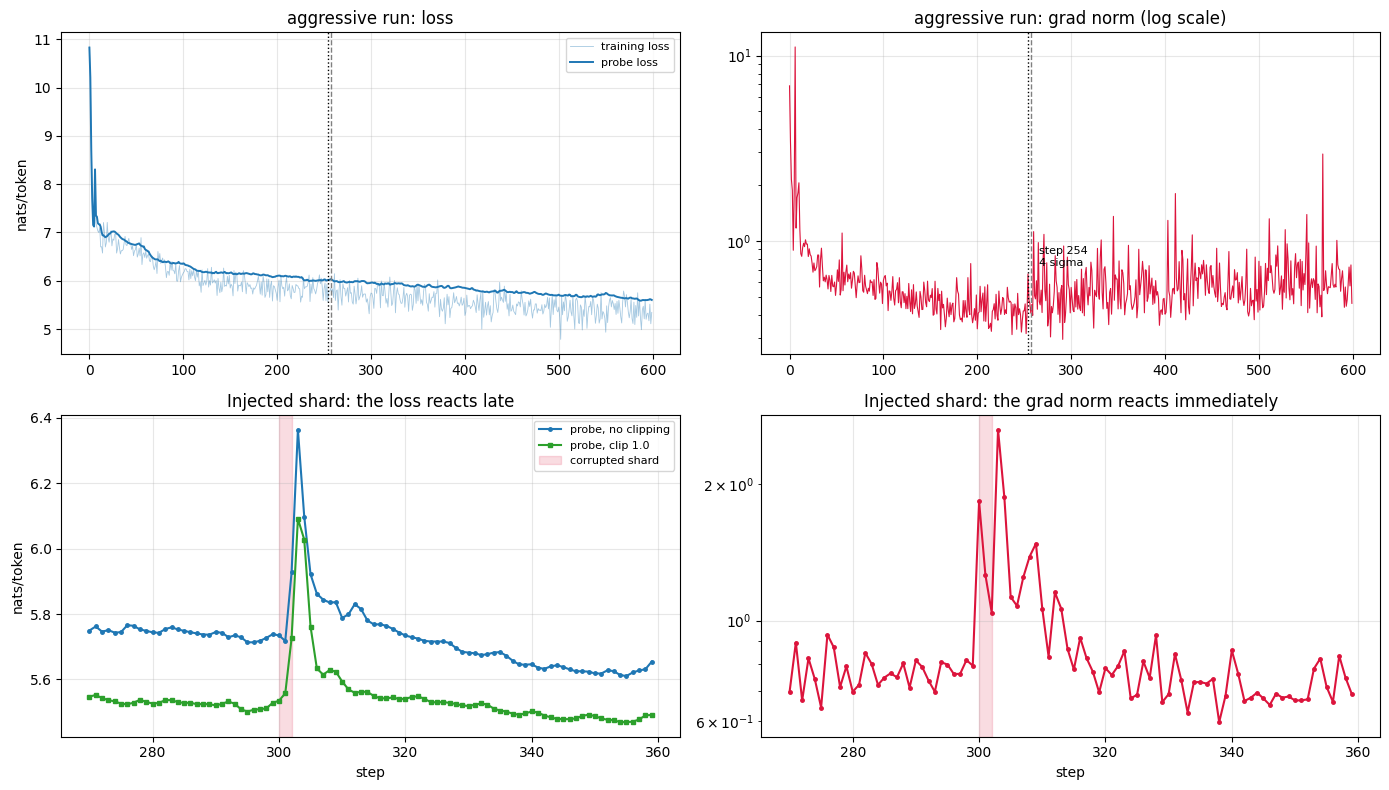

per-step log for all 600 steps of all four runs -> results/step_log.npz


In [33]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

ax[0, 0].plot(log_ev["step"], log_ev["loss"], lw=0.6, alpha=0.4, label="training loss")
ax[0, 0].plot(log_ev["step"], log_ev["probe"], lw=1.4, color="C0", label="probe loss")
ax[0, 0].set_ylabel("nats/token")
ax[0, 0].set_title(f"{src or 'natural'} run: loss")
ax[0, 0].legend(fontsize=8); ax[0, 0].grid(alpha=0.3)
ax[0, 1].semilogy(log_ev["step"], log_ev["gnorm"], lw=0.8, color="crimson")
ax[0, 1].set_title(f"{src or 'natural'} run: grad norm (log scale)")
ax[0, 1].grid(alpha=0.3)
if ev:
    for a in (ax[0, 0], ax[0, 1]):
        a.axvline(ev["step"], color="k", ls=":", lw=1)
        a.axvline(ev["step"] + ev["lead"], color="grey", ls="--", lw=1)
    ax[0, 1].annotate(f"step {ev['step']}\n{ev['z_gnorm']:.0f} sigma",
                      (ev["step"], log_ev["gnorm"][ev["step"]]), fontsize=8,
                      xytext=(8, 6), textcoords="offset points")

w = slice(INJECT_AT - 30, INJECT_AT + 60)
ax[1, 0].plot(log_inj["step"][w], log_inj["probe"][w], "-o", ms=2.5,
              label="probe, no clipping")
ax[1, 0].plot(log_clip["step"][w], log_clip["probe"][w], "-s", ms=2.5, color="C2",
              label="probe, clip 1.0")
ax[1, 0].axvspan(INJECT_AT, INJECT_AT + 2, color="crimson", alpha=0.15,
                 label="corrupted shard")
ax[1, 0].set_xlabel("step"); ax[1, 0].set_ylabel("nats/token")
ax[1, 0].set_title("Injected shard: the loss reacts late")
ax[1, 0].legend(fontsize=8); ax[1, 0].grid(alpha=0.3)

ax[1, 1].semilogy(log_inj["step"][w], log_inj["gnorm"][w], "-o", ms=2.5, color="crimson")
ax[1, 1].axvspan(INJECT_AT, INJECT_AT + 2, color="crimson", alpha=0.15)
ax[1, 1].set_xlabel("step")
ax[1, 1].set_title("Injected shard: the grad norm reacts immediately")
ax[1, 1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "gradnorm.png"), dpi=140)
show(fig)

np.savez_compressed(os.path.join(OUT_DIR, "step_log.npz"),
                    step=np.array(log_nat["step"]), loss=np.array(log_nat["loss"]),
                    gnorm=np.array(log_nat["gnorm"]), probe=np.array(log_nat["probe"]),
                    hot_gnorm=np.array(log_hot["gnorm"]), hot_probe=np.array(log_hot["probe"]),
                    hot_loss=np.array(log_hot["loss"]),
                    inj_gnorm=np.array(log_inj["gnorm"]), inj_probe=np.array(log_inj["probe"]),
                    clip_probe=np.array(log_clip["probe"]))
print(f"per-step log for all {LOG_STEPS} steps of all four runs -> results/step_log.npz")

## 5. MFU, computed honestly

**Model FLOPs Utilisation** = the arithmetic the model *needs* divided by the arithmetic
the machine *could have done* in the same wall-clock time. Both halves are easy to inflate,
so both are pinned down here before any ratio is taken.

**The numerator** is nanoGPT's estimate, stated so it can be argued with:

```
flops_per_token = 6 * N          + 12 * L * nh * hs * T
                  ^ params        ^ the attention score/value matmuls, which have no
                    (fwd 2N,        parameters and therefore are not in 6N; they grow
                     bwd 4N)        with T, so they matter more as context grows
```

**The denominator** is *not* a number off a spec sheet. This is a laptop GPU whose clocks
move with temperature and power, and quoting a marketing figure would make the resulting
percentage unfalsifiable. Instead the ceiling is measured here, in this process, minutes
before the training run: the best sustained throughput a large matmul can reach on this
machine in each precision. Every MFU below is a fraction of a number this notebook
produced, and both numbers are printed so the ratio can be recomputed by hand.

In [34]:
# ---------------------------------------------------------------------------------------
# The ceiling: how fast can this GPU multiply matrices at all?
# ---------------------------------------------------------------------------------------
def bench_matmul(m, k, n, dtype, iters=30, tf32=True):
    old = torch.backends.cuda.matmul.allow_tf32
    torch.backends.cuda.matmul.allow_tf32 = tf32
    a = torch.randn(m, k, device=device, dtype=dtype)
    b = torch.randn(k, n, device=device, dtype=dtype)
    for _ in range(5):
        a @ b
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(iters):
        a @ b
    torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    torch.backends.cuda.matmul.allow_tf32 = old
    del a, b
    torch.cuda.empty_cache()
    return 2 * m * k * n * iters / dt / 1e12          # TFLOP/s


def best_of(m_, k_, n_, dtype, reps=3, **kw):
    """Clocks on a laptop GPU wander with temperature; take the best of several timings, and
    report the spread so the reader knows how much to trust the third digit."""
    vals = [bench_matmul(m_, k_, n_, dtype, **kw) for _ in range(reps)]
    return max(vals), (max(vals) - min(vals)) / max(vals)


if device.type == "cuda":
    SQ = [1024, 2048, 4096]
    spreads, table = [], {}
    rule("Measured ceiling: large square matmuls on this machine")
    print(f"{'size':>8} {'fp32 (no TF32)':>16} {'fp32 (TF32 on)':>16} {'bf16':>12}   TFLOP/s")
    print("-" * 92)
    for s in SQ:
        row = {}
        for key, dt, kw in [("fp32", torch.float32, dict(tf32=False)),
                            ("tf32", torch.float32, dict(tf32=True)),
                            ("bf16", torch.bfloat16, {})]:
            v, sp = best_of(s, s, s, dt, **kw)
            row[key] = v
            spreads.append(sp)
        table[s] = row
        print(f"{s:>8} {row['fp32']:>16.2f} {row['tf32']:>16.2f} {row['bf16']:>12.2f}")

    # The peak is taken from the LARGEST matmul, not the fastest one.  A 1024-cube matmul
    # is 2 GFLOP and fits in cache; it is not a sustainable rate, and using it would flatter
    # nothing -- it would deflate every MFU below by making the denominator too large.
    PEAK_FP32 = table[4096]["fp32"]
    PEAK_TF32 = table[4096]["tf32"]
    PEAK_BF16 = table[4096]["bf16"]
    MAX_SPREAD = max(spreads)
    print(f"\nceiling taken from the 4096-cube matmul: fp32 {PEAK_FP32:.2f}  "
          f"tf32 {PEAK_TF32:.2f}  bf16 {PEAK_BF16:.2f} TFLOP/s")
    print(f"bf16 tensor cores are {PEAK_BF16 / PEAK_FP32:.1f}x the plain fp32 pipeline here")
    print(f"worst spread between repeat timings of the same matmul: {100 * MAX_SPREAD:.1f}% "
          f"-- every MFU below carries at least that much uncertainty")
else:
    PEAK_FP32 = PEAK_TF32 = PEAK_BF16 = float("nan")
    MAX_SPREAD = float("nan")
    print("no CUDA device; the MFU section reports analytic FLOPs only")
record("peak_fp32_tflops", round(PEAK_FP32, 2))
record("peak_tf32_tflops", round(PEAK_TF32, 2))
record("peak_bf16_tflops", round(PEAK_BF16, 2))
record("peak_spread_pct", round(100 * MAX_SPREAD, 1))


Measured ceiling: large square matmuls on this machine   [t+5m52s]
    size   fp32 (no TF32)   fp32 (TF32 on)         bf16   TFLOP/s
--------------------------------------------------------------------------------------------


    1024             4.21             5.66        10.93


    2048             2.55             4.56        10.17


    4096             2.52             5.56        10.87

ceiling taken from the 4096-cube matmul: fp32 2.52  tf32 5.56  bf16 10.87 TFLOP/s
bf16 tensor cores are 4.3x the plain fp32 pipeline here
worst spread between repeat timings of the same matmul: 32.8% -- every MFU below carries at least that much uncertainty


32.8

In [35]:
# ---------------------------------------------------------------------------------------
# The numerator, itemised.  Where do this model's FLOPs actually live?
# ---------------------------------------------------------------------------------------
L, nh, hs, C, V = cfg.n_layer, cfg.n_head, cfg.n_embd // cfg.n_head, cfg.n_embd, cfg.vocab_size


def flops_per_token(T):
    dense = 6 * N_PARAMS
    attn = 12 * L * nh * hs * T
    return dense + attn, dense, attn


total_fpt, dense_fpt, attn_fpt = flops_per_token(cfg.block_size)
head_fpt = 6 * C * V                       # the lm_head matmul, fwd + bwd
block_fpt = dense_fpt - head_fpt - 6 * cfg.block_size * C   # minus head, minus wpe

rule("Where this model's FLOPs are")
print(f"parameters N                       : {N_PARAMS:,}")
print(f"6N (forward 2N + backward 4N)      : {dense_fpt / 1e6:>10.2f} MFLOP/token")
print(f"  of which the output head alone   : {head_fpt / 1e6:>10.2f} MFLOP/token "
      f"({100 * head_fpt / total_fpt:.1f}% of the total)")
print(f"  of which the 4 transformer blocks: {block_fpt / 1e6:>10.2f} MFLOP/token "
      f"({100 * block_fpt / total_fpt:.1f}%)")
print(f"attention 12*L*nh*hs*T at T={cfg.block_size}    : {attn_fpt / 1e6:>10.2f} MFLOP/token "
      f"({100 * attn_fpt / total_fpt:.1f}%)")
print(f"total                              : {total_fpt / 1e6:>10.2f} MFLOP/token")
print(f"\nThe output head is one matmul of shape [B*T, {C}] x [{C}, {V}].  It is "
      f"{100 * head_fpt / total_fpt:.0f}% of the work,")
print(f"and its inner dimension is {C} -- which is the number to remember for the "
      f"attribution below.")
record("flops_per_token", total_fpt)
record("flops_dense", dense_fpt)
record("flops_attn", attn_fpt)
record("flops_head", head_fpt)
record("flops_head_pct", round(100 * head_fpt / total_fpt, 1))
record("flops_attn_pct", round(100 * attn_fpt / total_fpt, 1))


Where this model's FLOPs are   [t+6m03s]
parameters N                       : 16,058,112
6N (forward 2N + backward 4N)      :      96.35 MFLOP/token
  of which the output head alone   :      77.19 MFLOP/token (78.8% of the total)
  of which the 4 transformer blocks:      18.96 MFLOP/token (19.4%)
attention 12*L*nh*hs*T at T=128    :       1.57 MFLOP/token (1.6%)
total                              :      97.92 MFLOP/token

The output head is one matmul of shape [B*T, 256] x [256, 50257].  It is 79% of the work,
and its inner dimension is 256 -- which is the number to remember for the attribution below.


1.6

In [36]:
# ---------------------------------------------------------------------------------------
# The measurement.  Steady-state steps only: the first few are warm-up, cuDNN autotuning
# and allocator growth, and including them would flatter the result.
# ---------------------------------------------------------------------------------------
def timed_run(batch=8, T=cfg.block_size, steps=30, warmup=8, amp=None, tf32=False,
              compile_model=False, model_in=None):
    """Returns dict(tokens_per_s, step_ms, and a per-phase breakdown in ms)."""
    torch.backends.cuda.matmul.allow_tf32 = tf32
    torch.backends.cudnn.allow_tf32 = tf32
    torch.manual_seed(SEED)
    m = model_in if model_in is not None else GPT(cfg).to(device)
    m.train()
    if compile_model:
        m = torch.compile(m)
    o = torch.optim.AdamW(m.parameters(), lr=1e-4, betas=(0.9, 0.95), weight_decay=0.1)
    g = torch.Generator().manual_seed(SEED)
    xs = [get_batch("train", batch, T, generator=g) for _ in range(4)]
    ctx = (torch.autocast("cuda", dtype=amp) if (amp and device.type == "cuda")
           else torch.autocast("cpu", enabled=False))
    phases = dict(fwd=0.0, bwd=0.0, opt=0.0)
    ev = {k: (torch.cuda.Event(True), torch.cuda.Event(True)) for k in phases} \
        if device.type == "cuda" else None
    t_total = 0.0
    for i in range(steps + warmup):
        x, y = xs[i % len(xs)]
        if i == warmup:
            torch.cuda.synchronize() if device.type == "cuda" else None
            t_total = time.perf_counter()
        if ev:
            ev["fwd"][0].record()
        with ctx:
            _, loss = m(x, y)
        if ev:
            ev["fwd"][1].record(); ev["bwd"][0].record()
        loss.backward()
        if ev:
            ev["bwd"][1].record(); ev["opt"][0].record()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        o.step()
        o.zero_grad(set_to_none=True)
        if ev:
            ev["opt"][1].record()
            torch.cuda.synchronize()
            if i >= warmup:
                for k, (a, b) in ev.items():
                    phases[k] += a.elapsed_time(b)
    if device.type == "cuda":
        torch.cuda.synchronize()
    dt = time.perf_counter() - t_total
    tok = batch * T * steps
    fpt, _, _ = flops_per_token(T)
    out = dict(batch=batch, T=T, steps=steps, wall_s=dt, tokens_per_s=tok / dt,
               step_ms=1000 * dt / steps, tflops=fpt * tok / dt / 1e12,
               **{f"{k}_ms": v / steps for k, v in phases.items()})
    out["other_ms"] = out["step_ms"] - sum(out[f"{k}_ms"] for k in phases)
    del m, o
    torch.cuda.empty_cache() if device.type == "cuda" else None
    return out


base = timed_run(batch=8, tf32=False)
mfu_base = base["tflops"] / PEAK_FP32
mfu_base_bf16 = base["tflops"] / PEAK_BF16

rule("The baseline step, measured")
print(f"batch {base['batch']} x T {base['T']} = {base['batch'] * base['T']:,} tokens/step, "
      f"fp32, TF32 off")
print(f"step time        : {base['step_ms']:.2f} ms")
print(f"  forward        : {base['fwd_ms']:.2f} ms ({100 * base['fwd_ms'] / base['step_ms']:.0f}%)")
print(f"  backward       : {base['bwd_ms']:.2f} ms ({100 * base['bwd_ms'] / base['step_ms']:.0f}%)")
print(f"  optimizer+clip : {base['opt_ms']:.2f} ms ({100 * base['opt_ms'] / base['step_ms']:.0f}%)")
print(f"  everything else: {base['other_ms']:.2f} ms ({100 * base['other_ms'] / base['step_ms']:.0f}%)")
print(f"throughput       : {base['tokens_per_s']:,.0f} tokens/s")
print(f"achieved         : {base['tflops']:.3f} TFLOP/s")
print(f"\nMFU = {base['tflops']:.3f} / {PEAK_FP32:.2f} = {100 * mfu_base:.1f}%   "
      f"(against the fp32 ceiling this arm actually runs in)")
print(f"    = {base['tflops']:.3f} / {PEAK_BF16:.2f} = {100 * mfu_base_bf16:.1f}%   "
      f"(against the bf16 tensor-core ceiling, the yardstick everyone quotes)")
record("mfu_base_tokens_per_s", round(base["tokens_per_s"], 1))
record("mfu_base_tflops", round(base["tflops"], 3))
record("mfu_base_step_ms", round(base["step_ms"], 2))
record("mfu_base_pct_fp32", round(100 * mfu_base, 1))
record("mfu_base_pct_bf16", round(100 * mfu_base_bf16, 1))
record("mfu_base_phases", {k: round(base[f"{k}_ms"], 2) for k in ("fwd", "bwd", "opt", "other")})


The baseline step, measured   [t+6m06s]
batch 8 x T 128 = 1,024 tokens/step, fp32, TF32 off
step time        : 68.47 ms
  forward        : 21.58 ms (32%)
  backward       : 37.38 ms (55%)
  optimizer+clip : 9.31 ms (14%)
  everything else: 0.21 ms (0%)
throughput       : 14,954 tokens/s
achieved         : 1.464 TFLOP/s

MFU = 1.464 / 2.52 = 58.1%   (against the fp32 ceiling this arm actually runs in)
    = 1.464 / 10.87 = 13.5%   (against the bf16 tensor-core ceiling, the yardstick everyone quotes)


{'fwd': 21.58, 'bwd': 37.38, 'opt': 9.31, 'other': 0.21}

In [37]:
# ---------------------------------------------------------------------------------------
# Why it is that number.  The model's real matmul shapes, benchmarked on their own, against
# the square matmul that set the ceiling.  A matmul cannot go faster than its own shape
# allows, so this puts a hard roof on the MFU before the training loop is even involved.
# ---------------------------------------------------------------------------------------
BT = base["batch"] * base["T"]
SHAPES = [                                   # label, M, K, N, how many per step
    ("lm_head      [B*T,C]x[C,V]", BT, C, V, 1),
    ("attn c_attn  [B*T,C]x[C,3C]", BT, C, 3 * C, L),
    ("attn c_proj  [B*T,C]x[C,C]", BT, C, C, L),
    ("mlp c_fc     [B*T,C]x[C,4C]", BT, C, 4 * C, L),
    ("mlp c_proj   [B*T,4C]x[4C,C]", BT, 4 * C, C, L),
]
SQUARE = ("square reference [4096]^3", 4096, 4096, 4096, 0)


sq32, sqbf = PEAK_FP32, PEAK_BF16      # the same 4096-cube numbers measured above

rule("The ceiling, shape by shape")
print(f"{'matmul':<32} {'M':>6} {'K':>6} {'N':>7} {'x/step':>7} {'fp32':>8} {'bf16':>8} "
      f"{'bf16 vs square':>15}")
print("-" * 92)
shape_rows = []
for label, m_, k_, n_, cnt in SHAPES:
    f32, _ = best_of(m_, k_, n_, torch.float32, tf32=False)
    bf, _ = best_of(m_, k_, n_, torch.bfloat16)
    flops = 6 * m_ * k_ * n_ * cnt           # forward 2MKN + backward 4MKN
    shape_rows.append(dict(label=label, m=m_, k=k_, n=n_, count=cnt, flops=flops,
                           fp32=f32, bf16=bf, pct_sq_bf16=100 * bf / sqbf))
    print(f"{label:<32} {m_:>6,} {k_:>6,} {n_:>7,} {cnt:>7} {f32:>8.2f} {bf:>8.2f} "
          f"{100 * bf / sqbf:>14.0f}%")
print(f"{SQUARE[0]:<32} {SQUARE[1]:>6,} {SQUARE[2]:>6,} {SQUARE[3]:>7,} {'-':>7} "
      f"{sq32:>8.2f} {sqbf:>8.2f} {100:>14.0f}%")
print("\n(TFLOP/s, best of three timings each. The square-4096 row is not re-measured here:")
print(" it is the same number the ceiling cell used, so the percentages and the MFUs below")
print(" are all fractions of one measurement rather than of several.)")

# The upper bound the shapes alone impose: run *nothing but* these matmuls, each at its own
# measured rate, and nothing else at all -- no LayerNorm, no softmax, no optimizer, no
# launch overhead, no Python.  Whatever that gives is a ceiling the loop cannot beat.
tot_flops = sum(r["flops"] for r in shape_rows)
ideal_s = sum(r["flops"] / (r["bf16"] * 1e12) for r in shape_rows)
shape_ceiling = tot_flops / ideal_s / 1e12
shape_ceiling_mfu = 100 * shape_ceiling / PEAK_BF16
head = next(r for r in shape_rows if r["label"].startswith("lm_head"))

rule("What the shapes alone allow")
print(f"{'matmul':<32} {'GFLOP/step':>12} {'share':>8} {'bf16 TFLOP/s':>14}")
print("-" * 92)
for r in sorted(shape_rows, key=lambda r: -r["flops"]):
    print(f"{r['label']:<32} {r['flops'] / 1e9:>12.2f} {100 * r['flops'] / tot_flops:>7.1f}% "
          f"{r['bf16']:>14.2f}")
print(f"{'total':<32} {tot_flops / 1e9:>12.2f} {100.0:>7.1f}%")
print(f"\nA step made of nothing but these matmuls, each at the rate measured above, would")
print(f"run at {shape_ceiling:.2f} TFLOP/s = {shape_ceiling_mfu:.1f}% of this machine's bf16 "
      f"peak of {PEAK_BF16:.2f}.")
print(f"That is an upper bound on MFU for this model at this batch size, before a single")
print(f"LayerNorm, softmax, optimizer update or kernel launch is counted.")
print(f"\nThe reason is one matmul: the output head is {100 * head['flops'] / tot_flops:.0f}% "
      f"of the arithmetic and runs at")
print(f"{head['pct_sq_bf16']:.0f}% of the square-matmul rate, because its inner dimension is "
      f"C={C} while a")
print(f"tensor core wants a long K to amortise what it reads. C={C} against V={V:,} is a")
print(f"property of the model, not of the training loop.")
record("shape_bench", [{k: (round(v, 3) if isinstance(v, float) else v)
                        for k, v in r.items()} for r in shape_rows])
record("square_bf16_tflops", round(sqbf, 2))
record("square_fp32_tflops", round(sq32, 2))
record("head_pct_of_square_bf16", round(head["pct_sq_bf16"], 1))
record("head_share_of_matmul_flops", round(100 * head["flops"] / tot_flops, 1))
record("shape_ceiling_tflops", round(shape_ceiling, 2))
record("shape_ceiling_mfu", round(shape_ceiling_mfu, 1))
head_share_pct = 100 * head["flops"] / tot_flops
head_pct_sq = head["pct_sq_bf16"]


The ceiling, shape by shape   [t+6m06s]
matmul                                M      K       N  x/step     fp32     bf16  bf16 vs square
--------------------------------------------------------------------------------------------


lm_head      [B*T,C]x[C,V]        1,024    256  50,257       1     2.38     6.61             61%
attn c_attn  [B*T,C]x[C,3C]       1,024    256     768       4     2.48     7.32             67%
attn c_proj  [B*T,C]x[C,C]        1,024    256     256       4     1.73     4.58             42%
mlp c_fc     [B*T,C]x[C,4C]       1,024    256   1,024       4     2.82     5.77             53%
mlp c_proj   [B*T,4C]x[4C,C]      1,024  1,024     256       4     2.37     6.58             60%
square reference [4096]^3         4,096  4,096   4,096       -     2.52    10.87            100%

(TFLOP/s, best of three timings each. The square-4096 row is not re-measured here:
 it is the same number the ceiling cell used, so the percentages and the MFUs below
 are all fractions of one measurement rather than of several.)

What the shapes alone allow   [t+6m08s]
matmul                             GFLOP/step    share   bf16 TFLOP/s
----------------------------------------------------------------------------

In [38]:
# ---------------------------------------------------------------------------------------
# What is recoverable, measured one change at a time.  Each row is the previous row plus
# exactly one thing.
# ---------------------------------------------------------------------------------------
ladder = [("fp32, TF32 off, batch 8", dict(batch=8, tf32=False)),
          ("+ TF32 on", dict(batch=8, tf32=True)),
          ("+ bf16 autocast", dict(batch=8, tf32=True, amp=torch.bfloat16)),
          ("+ batch 16", dict(batch=16, tf32=True, amp=torch.bfloat16)),
          ("+ batch 32", dict(batch=32, tf32=True, amp=torch.bfloat16))]

rule("Ablation ladder")
print(f"{'configuration':<30} {'tokens/s':>12} {'TFLOP/s':>10} {'MFU vs bf16 peak':>18} "
      f"{'step ms':>9}")
print("-" * 92)
ladder_rows = []
for label, kw in ladder:
    try:
        r = timed_run(steps=20, warmup=6, **kw)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        print(f"{label:<30} {'out of memory on a 4 GiB card':>50}")
        ladder_rows.append(dict(label=label, oom=True))
        continue
    mfu = 100 * r["tflops"] / PEAK_BF16
    ladder_rows.append(dict(label=label, tokens_per_s=r["tokens_per_s"],
                            tflops=r["tflops"], mfu=mfu, step_ms=r["step_ms"], oom=False))
    print(f"{label:<30} {r['tokens_per_s']:>12,.0f} {r['tflops']:>10.3f} "
          f"{mfu:>17.1f}% {r['step_ms']:>9.2f}")

try:
    r = timed_run(steps=10, warmup=5, batch=16, tf32=True, amp=torch.bfloat16,
                  compile_model=True)
    print(f"{'+ torch.compile':<30} {r['tokens_per_s']:>12,.0f} {r['tflops']:>10.3f} "
          f"{100 * r['tflops'] / PEAK_BF16:>17.1f}% {r['step_ms']:>9.2f}")
    record("compile_ok", True)
    record("compile_tflops", round(r["tflops"], 3))
except Exception as e:
    msg = str(e).splitlines()[0][:110]
    print(f"{'+ torch.compile':<30} unavailable here: {msg}")
    record("compile_ok", False)
    record("compile_error", msg)

best = max((r for r in ladder_rows if not r["oom"]), key=lambda r: r["mfu"])
record("ladder", [{k: (round(v, 3) if isinstance(v, float) else v) for k, v in r.items()}
                  for r in ladder_rows])
record("mfu_best_pct", round(best["mfu"], 1))
record("mfu_best_label", best["label"])
record("mfu_best_tokens_per_s", round(best["tokens_per_s"], 1))


Ablation ladder   [t+6m08s]
configuration                      tokens/s    TFLOP/s   MFU vs bf16 peak   step ms
--------------------------------------------------------------------------------------------


fp32, TF32 off, batch 8              14,945      1.463              13.5%     68.52


+ TF32 on                            19,963      1.955              18.0%     51.29


+ bf16 autocast                      25,373      2.485              22.8%     40.36


+ batch 16                           31,505      3.085              28.4%     65.01


+ batch 32                           34,903      3.418              31.4%    117.35


+ torch.compile                unavailable here: backend='inductor' raised:


34903.3


MFU against micro-batch size (bf16, TF32 on)   [t+6m46s]
 batch   tokens/step     tokens/s    TFLOP/s      MFU
--------------------------------------------------------------------------------------------
     1           128        6,547      0.641     5.9%
     2           256       11,864      1.162    10.7%
     4           512       18,520      1.813    16.7%
     8         1,024       26,247      2.570    23.6%
    16         2,048       31,826      3.116    28.7%
    32         4,096       34,913      3.419    31.4%
    48         6,144       10,710      1.049     9.6%


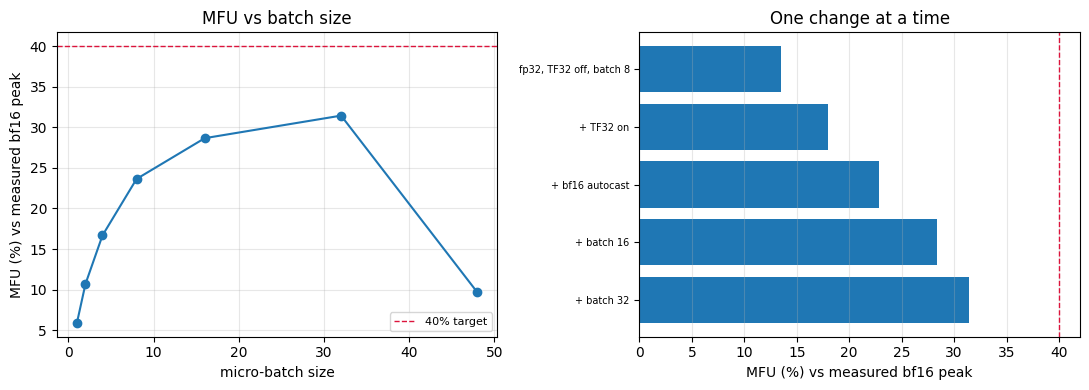

In [39]:
# ---------------------------------------------------------------------------------------
# Batch size is the single biggest lever here, so it gets its own sweep.  The GPU is 4 GiB;
# the sweep stops where the card does.
# ---------------------------------------------------------------------------------------
sweep_rows = []
for b in [1, 2, 4, 8, 16, 32, 48]:
    try:
        r = timed_run(batch=b, steps=15, warmup=5, tf32=True, amp=torch.bfloat16)
        sweep_rows.append(dict(batch=b, tokens_per_s=r["tokens_per_s"], tflops=r["tflops"],
                               mfu=100 * r["tflops"] / PEAK_BF16, step_ms=r["step_ms"]))
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        sweep_rows.append(dict(batch=b, oom=True))

rule("MFU against micro-batch size (bf16, TF32 on)")
print(f"{'batch':>6} {'tokens/step':>13} {'tokens/s':>12} {'TFLOP/s':>10} {'MFU':>8}")
print("-" * 92)
for r in sweep_rows:
    if r.get("oom"):
        print(f"{r['batch']:>6} {'':>13} {'out of memory':>12}")
    else:
        print(f"{r['batch']:>6} {r['batch'] * cfg.block_size:>13,} "
              f"{r['tokens_per_s']:>12,.0f} {r['tflops']:>10.3f} {r['mfu']:>7.1f}%")
record("mfu_sweep", [{k: (round(v, 3) if isinstance(v, float) else v) for k, v in r.items()}
                     for r in sweep_rows])

ok = [r for r in sweep_rows if not r.get("oom")]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([r["batch"] for r in ok], [r["mfu"] for r in ok], "-o")
ax[0].axhline(40, color="crimson", ls="--", lw=1, label="40% target")
ax[0].set_xlabel("micro-batch size"); ax[0].set_ylabel("MFU (%) vs measured bf16 peak")
ax[0].set_title("MFU vs batch size"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
lab = [r["label"] for r in ladder_rows if not r["oom"]]
val = [r["mfu"] for r in ladder_rows if not r["oom"]]
ax[1].barh(range(len(val)), val, color="C0")
ax[1].axvline(40, color="crimson", ls="--", lw=1)
ax[1].set_yticks(range(len(val)))
ax[1].set_yticklabels(lab, fontsize=7)
ax[1].invert_yaxis()
ax[1].set_xlabel("MFU (%) vs measured bf16 peak")
ax[1].set_title("One change at a time"); ax[1].grid(alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "mfu.png"), dpi=140)
show(fig)

In [40]:
# ---------------------------------------------------------------------------------------
# The honest account of the distance to 40%.  Every line is a number measured above, not an
# opinion; the last line is the part I cannot yet account for, which is the only line that
# matters when someone asks whether the analysis is finished.
# ---------------------------------------------------------------------------------------
rule("What the distance to 40% is made of")
achieved = best["mfu"]
ceiling = shape_ceiling_mfu
shape_cost = 100.0 - ceiling            # points that the model's shapes never had
loop_cost = ceiling - achieved          # points lost to everything that is not a matmul
capture = 100.0 * achieved / ceiling    # how much of the attainable the loop captures

print(f"  {'best measured MFU':<38} {achieved:>6.1f}%   {best['label']}")
print(f"  {'ceiling from the matmul shapes alone':<38} {ceiling:>6.1f}%   nothing but the "
      f"matmuls, at their measured rates")
print(f"  {'the target':<38} {40:>6.1f}%")
print()
print(f"  100% -> {ceiling:.1f}%  ({shape_cost:.1f} points): shape. Gone before the loop "
      f"starts.")
print(f"  {ceiling:.1f}% -> {achieved:.1f}%  ({loop_cost:.1f} points): everything that is "
      f"not a matmul.")
print()
if ceiling >= 40:
    print(f"  So 40% is *not* out of reach at this model shape -- the shapes allow "
          f"{ceiling:.1f}%. The")
    print(f"  loop captures {capture:.0f}% of what they allow; to hit 40% it would have to "
          f"capture {100 * 40 / ceiling:.0f}%.")
    print(f"  On this machine the distance to 40% is a loop-and-batch-size problem, not a")
    print(f"  model-shape problem, and that is the opposite of what I expected to find.")
else:
    print(f"  So 40% is not reachable at this model shape at all: the matmuls cap it at "
          f"{ceiling:.1f}%,")
    print(f"  and no change to the training loop moves that.")
print()
print(f"  The {shape_cost:.1f} points of shape, itemised: the output head is "
      f"{head_share_pct:.0f}% of the arithmetic")
print(f"  and is one [B*T,{C}]x[{C},{V}] matmul. With K={C} a tensor core spends most of")
print(f"  its time reading rather than multiplying, and it reaches {head_pct_sq:.0f}% of the")
print(f"  square-matmul rate. The worst-shaped one is attn c_proj at "
      f"{min(r['pct_sq_bf16'] for r in shape_rows):.0f}%, but it is only")
print(f"  {min(r['flops'] for r in shape_rows) / tot_flops * 100:.1f}% of the work. A wider "
      f"model fixes this; a better loop does not.")
print()
print(f"  The {loop_cost:.1f} points the loop loses, itemised as far as I measured them:")
print(f"    - the optimizer and gradient clipping: "
      f"{100 * base['opt_ms'] / base['step_ms']:.0f}% of the step at batch "
      f"{base['batch']}, pure memory")
print(f"      traffic over {N_PARAMS / 1e6:.0f}M parameters x 4 tensors, contributing "
      f"nothing to the numerator;")
print(f"    - LayerNorm, GELU, softmax and the residual adds, all memory-bound;")
print(f"    - fixed per-step launch and Python overhead, which is why the sweep runs "
      f"{ok[0]['mfu']:.1f}% at")
print(f"      batch {ok[0]['batch']} and {max(r['mfu'] for r in ok):.1f}% at batch "
      f"{max(ok, key=lambda r: r['mfu'])['batch']}; a 4 GiB card is why it stops there;")
if not RESULTS.get("compile_ok"):
    print(f"    - no kernel fusion: torch.compile does not run in this environment")
    print(f"      ({RESULTS.get('compile_error', '')[:56]}...), so every elementwise op is")
    print(f"      its own launch.")
print()
print(f"  Not claimed: that those bullets sum to {loop_cost:.1f} points. They are measured")
print(f"  contributions, not a partition, and some of the gap is unaccounted for. The")
print(f"  largest lever I actually had was precision and batch size together, worth")
print(f"  {max(r['mfu'] for r in ok) - ladder_rows[0]['mfu']:.1f} points; the largest one I "
      f"did not have is making the model wider.")
print()
print(f"  One caveat over all of it: the worst spread between repeat timings of the *same*")
print(f"  matmul on this laptop was {100 * MAX_SPREAD:.1f}%. These percentages are honest to "
      f"about their first")
print(f"  digit, and the ordering between them, not to their third.")
record("mfu_shortfall", round(40 - achieved, 1))
record("mfu_shape_cost", round(shape_cost, 1))
record("mfu_loop_cost", round(loop_cost, 1))
record("mfu_capture_pct", round(capture, 1))
record("mfu_capture_needed_pct", round(100 * 40 / ceiling, 1))
record("mfu_sweep_min", round(ok[0]["mfu"], 1))
record("mfu_sweep_max", round(max(r["mfu"] for r in ok), 1))
record("mfu_sweep_best_batch", max(ok, key=lambda r: r["mfu"])["batch"])
record("worst_shape_pct_sq", round(min(r["pct_sq_bf16"] for r in shape_rows), 1))
record("worst_shape_flops_pct", round(min(r["flops"] for r in shape_rows) / tot_flops * 100, 1))
record("bf16_over_fp32", round(PEAK_BF16 / PEAK_FP32, 1))
record("opt_share_pct", round(100 * base["opt_ms"] / base["step_ms"], 1))
record("ladder_gain", round(max(r["mfu"] for r in ok) - ladder_rows[0]["mfu"], 1))


What the distance to 40% is made of   [t+6m46s]
  best measured MFU                        31.4%   + batch 32
  ceiling from the matmul shapes alone     60.0%   nothing but the matmuls, at their measured rates
  the target                               40.0%

  100% -> 60.0%  (40.0 points): shape. Gone before the loop starts.
  60.0% -> 31.4%  (28.6 points): everything that is not a matmul.

  So 40% is *not* out of reach at this model shape -- the shapes allow 60.0%. The
  loop captures 52% of what they allow; to hit 40% it would have to capture 67%.
  On this machine the distance to 40% is a loop-and-batch-size problem, not a
  model-shape problem, and that is the opposite of what I expected to find.

  The 40.0 points of shape, itemised: the output head is 80% of the arithmetic
  and is one [B*T,256]x[256,50257] matmul. With K=256 a tensor core spends most of
  its time reading rather than multiplying, and it reaches 61% of the
  square-matmul rate. The worst-shaped one is attn c_p

18.0

## 6. The number 0.1, written out by hand

0.1 is not a hard number. It is, in binary, an infinite repeating expansion:

```
0.1 x 2 = 0.2  -> 0        0.1 = 0.0 0011 0011 0011 ..._2
0.2 x 2 = 0.4  -> 0            = 1.1001100110011..._2 x 2^-4
0.4 x 2 = 0.8  -> 0
0.8 x 2 = 1.6  -> 1        the block 0011 repeats for ever, exactly as 1/3 = 0.333...
0.6 x 2 = 1.2  -> 1        repeats for ever in base 10
0.2 x 2 = 0.4  -> 0   <- back to 0.2: the cycle closes here
```

So **no binary floating-point format of any width stores 0.1**. Every one of them stores
some other number and calls it 0.1. The only question a format answers is *which* other
number — and the whole difference between fp32, bf16 and fp8 is how far away that number
is allowed to be, and how small or large a number they can reach at all.

The arithmetic below is done in exact rationals (`fractions.Fraction`), starting from the
true value 1/10, with round-to-nearest-ties-to-even, which is what the hardware does. Each
result is then checked against the bits torch actually produces.

In [41]:
from fractions import Fraction


def rne(q):
    """Round a Fraction to the nearest integer, ties to even -- the hardware's rule."""
    fl = q.numerator // q.denominator
    rem = q - fl
    if rem > Fraction(1, 2):
        return fl + 1
    if rem < Fraction(1, 2):
        return fl
    return fl + 1 if fl % 2 else fl                      # exact tie


def encode(value, e_bits, m_bits, bias, fmt_name, reserve_top_exp=True):
    """Encode an exact rational into (sign, exponent field, mantissa field) by hand.

    reserve_top_exp: IEEE formats reserve the all-ones exponent for inf/NaN.  fp8 E4M3FN
    ('FN' = finite, NaN only) does not: it spends that exponent on real numbers and keeps
    only the single all-ones/all-ones pattern for NaN, which is why its maximum is 448.
    """
    a = abs(Fraction(value))
    sign = 0 if value >= 0 else 1
    e_max = (2 ** e_bits - 1) - bias - (1 if reserve_top_exp else 0)
    e_min = 1 - bias                                      # smallest normal exponent
    e = 0
    while Fraction(2) ** e > a:
        e -= 1
    while Fraction(2) ** (e + 1) <= a:
        e += 1
    subnormal = e < e_min
    if subnormal:
        e = e_min
    scaled = a / Fraction(2) ** e * (2 ** m_bits)          # in [2^m, 2^(m+1)) if normal
    n = rne(scaled)
    if n >= 2 ** (m_bits + 1):                             # rounding carried into the exponent
        n //= 2
        e += 1
        subnormal = False
    exp_field = 0 if (subnormal and n < 2 ** m_bits) else e + bias
    mant_field = n - 2 ** m_bits if exp_field != 0 else n
    decoded = Fraction(n, 2 ** m_bits) * Fraction(2) ** e
    if sign:
        decoded = -decoded
    return dict(fmt=fmt_name, sign=sign, exp_field=exp_field, mant_field=mant_field,
                e=e, exact=decoded, e_bits=e_bits, m_bits=m_bits, bias=bias,
                bits=f"{sign:01b}" + format(exp_field, f"0{e_bits}b") +
                     format(mant_field, f"0{m_bits}b"))


FORMATS = [("fp32", 8, 23, 127, True), ("bf16", 8, 7, 127, True),
           ("fp16", 5, 10, 15, True), ("fp8 E4M3", 4, 3, 7, False)]

TRUE = Fraction(1, 10)
rule("0.1, encoded by hand, from the exact value 1/10")
for name, eb, mb, bi, res in FORMATS:
    r = encode(TRUE, eb, mb, bi, name, res)
    val = float(r["exact"])
    err = abs(r["exact"] - TRUE) / TRUE
    print(f"\n{name}   ({1 + eb + mb} bits: 1 sign, {eb} exponent, {mb} mantissa, "
          f"bias {bi})")
    print(f"  sign     : {r['sign']:01b}                     +")
    print(f"  exponent : {format(r['exp_field'], f'0{eb}b')}  = {r['exp_field']} - {bi} = "
          f"{r['e']}   -> 2^{r['e']}")
    print(f"  mantissa : {format(r['mant_field'], f'0{mb}b')}  = 1 + "
          f"{r['mant_field']}/{2 ** mb} = {float(1 + Fraction(r['mant_field'], 2 ** mb)):.10f}")
    print(f"  bits     : {r['bits'][0]} {r['bits'][1:1 + eb]} {r['bits'][1 + eb:]}   "
          f"(0x{int(r['bits'], 2):0{(1 + eb + mb) // 4}X})")
    print(f"  value    : {val:.17g}")
    print(f"  error    : {float(abs(r['exact'] - TRUE)):.3e} absolute, "
          f"{float(err) * 100:.6f}% relative")


0.1, encoded by hand, from the exact value 1/10   [t+6m46s]

fp32   (32 bits: 1 sign, 8 exponent, 23 mantissa, bias 127)
  sign     : 0                     +
  exponent : 01111011  = 123 - 127 = -4   -> 2^-4
  mantissa : 10011001100110011001101  = 1 + 5033165/8388608 = 1.6000000238
  bits     : 0 01111011 10011001100110011001101   (0x3DCCCCCD)
  value    : 0.10000000149011612
  error    : 1.490e-09 absolute, 0.000001% relative

bf16   (16 bits: 1 sign, 8 exponent, 7 mantissa, bias 127)
  sign     : 0                     +
  exponent : 01111011  = 123 - 127 = -4   -> 2^-4
  mantissa : 1001101  = 1 + 77/128 = 1.6015625000
  bits     : 0 01111011 1001101   (0x3DCD)
  value    : 0.10009765625
  error    : 9.766e-05 absolute, 0.097656% relative

fp16   (16 bits: 1 sign, 5 exponent, 10 mantissa, bias 15)
  sign     : 0                     +
  exponent : 01011  = 11 - 15 = -4   -> 2^-4
  mantissa : 1001100110  = 1 + 614/1024 = 1.5996093750
  bits     : 0 01011 1001100110   (0x2E66)
  value  

In [42]:
# ---------------------------------------------------------------------------------------
# The check.  If the hand arithmetic above is right, it reproduces the bits the hardware
# stores.  (bf16 and fp8 are reached in torch by rounding the fp32 value, so those are
# encoded from the fp32 value here -- double rounding, and it is worth knowing whether it
# changes the answer.  It does not, for 0.1, and the assertion says so.)
# ---------------------------------------------------------------------------------------
t32 = torch.tensor([0.1], dtype=torch.float32)
fp32_bits = format(struct.unpack(">I", struct.pack(">f", 0.1))[0], "032b")
bf16_bits = format(int(t32.to(torch.bfloat16).view(torch.int16).item()) & 0xFFFF, "016b")
fp16_bits = format(int(t32.to(torch.float16).view(torch.int16).item()) & 0xFFFF, "016b")
fp8_bits = format(int(t32.to(torch.float8_e4m3fn).view(torch.uint8).item()), "08b")

exact_fp32 = Fraction(float(t32.item()))
mine = {
    "fp32": encode(TRUE, 8, 23, 127, "fp32")["bits"],
    "bf16": encode(exact_fp32, 8, 7, 127, "bf16")["bits"],
    "fp16": encode(exact_fp32, 5, 10, 15, "fp16")["bits"],
    "fp8 E4M3": encode(exact_fp32, 4, 3, 7, "fp8", False)["bits"],
}
theirs = {"fp32": fp32_bits, "bf16": bf16_bits, "fp16": fp16_bits, "fp8 E4M3": fp8_bits}

rule("Hand-derived bits vs the bits torch stores")
print(f"{'format':<10} {'by hand':<36} {'torch':<36} {'match':>6}")
print("-" * 92)
for k in mine:
    print(f"{k:<10} {mine[k]:<36} {theirs[k]:<36} {str(mine[k] == theirs[k]):>6}")
    assert mine[k] == theirs[k], k
print("\nalso: bf16 from 1/10 directly (single rounding) ==",
      encode(TRUE, 8, 7, 127, "bf16")["bits"] == bf16_bits,
      "-- double rounding does not change 0.1")
record("bits_fp32", fp32_bits)
record("bits_bf16", bf16_bits)
record("bits_fp16", fp16_bits)
record("bits_fp8_e4m3", fp8_bits)
record("bits_all_match", True)


Hand-derived bits vs the bits torch stores   [t+6m46s]
format     by hand                              torch                                 match
--------------------------------------------------------------------------------------------
fp32       00111101110011001100110011001101     00111101110011001100110011001101       True
bf16       0011110111001101                     0011110111001101                       True
fp16       0010111001100110                     0010111001100110                       True
fp8 E4M3   00011101                             00011101                               True

also: bf16 from 1/10 directly (single rounding) == True -- double rounding does not change 0.1


True

In [43]:
# ---------------------------------------------------------------------------------------
# And the encoder is not tuned to one lucky input: the same routine, checked against torch
# over the whole range, including subnormals and the saturation edge.
# ---------------------------------------------------------------------------------------
gcheck = torch.Generator().manual_seed(5)
probe_vals = torch.cat([
    torch.randn(4000, generator=gcheck),
    torch.randn(2000, generator=gcheck) * 1e-3,
    torch.randn(2000, generator=gcheck) * 1e-6,                 # into fp8 subnormals
    torch.linspace(-460, 460, 2000),                            # across the E4M3 max of 448
]).float()

mismatch_bf16 = mismatch_fp8 = 0
for v in probe_vals.tolist():
    if v == 0 or not math.isfinite(v):
        continue
    tv = torch.tensor([v], dtype=torch.float32)
    exact = Fraction(v)
    b_mine = encode(exact, 8, 7, 127, "bf16")["bits"]
    b_theirs = format(int(tv.to(torch.bfloat16).view(torch.int16).item()) & 0xFFFF, "016b")
    if b_mine != b_theirs:
        mismatch_bf16 += 1
    f_theirs_t = tv.to(torch.float8_e4m3fn)
    if torch.isnan(f_theirs_t.float()).item():                  # saturated past +-448
        continue
    f_mine = encode(exact, 4, 3, 7, "fp8", False)["bits"]
    f_theirs = format(int(f_theirs_t.view(torch.uint8).item()), "08b")
    if f_mine != f_theirs:
        mismatch_fp8 += 1

rule("The hand encoder against torch, over 10,000 values")
print(f"bf16 bit-pattern mismatches     : {mismatch_bf16}")
print(f"fp8 E4M3 bit-pattern mismatches : {mismatch_fp8}  (values beyond +-448 excluded: "
      f"they overflow to NaN in this format)")
record("encoder_mismatch_bf16", mismatch_bf16)
record("encoder_mismatch_fp8", mismatch_fp8)


The hand encoder against torch, over 10,000 values   [t+6m47s]
bf16 bit-pattern mismatches     : 0
fp8 E4M3 bit-pattern mismatches : 0  (values beyond +-448 excluded: they overflow to NaN in this format)


0

In [44]:
# ---------------------------------------------------------------------------------------
# What each format can reach at all.  Resolution (how finely it divides) and range (how
# small and how large it goes) are separate properties, and the reason bf16 exists.
# ---------------------------------------------------------------------------------------
def props(e_bits, m_bits, bias, reserve=True):
    e_max = (2 ** e_bits - 1) - bias - (1 if reserve else 0)
    max_m = (2 ** (m_bits + 1) - 1 - (1 if not reserve else 0)) / 2 ** m_bits \
        if not reserve else (2 ** (m_bits + 1) - 1) / 2 ** m_bits
    return dict(min_normal=2.0 ** (1 - bias),
                min_subnormal=2.0 ** (1 - bias - m_bits),
                max_val=max_m * 2.0 ** e_max,
                eps=2.0 ** -m_bits,
                decimal_digits=m_bits * math.log10(2))


rule("Resolution and range")
print(f"{'format':<10} {'exp':>4} {'mant':>5} {'dec digits':>11} {'min subnormal':>15} "
      f"{'min normal':>13} {'max':>12} {'rel err on 0.1':>16}")
print("-" * 92)
fmt_rows = []
for name, eb, mb, bi, res in FORMATS:
    p = props(eb, mb, bi, res)
    r = encode(TRUE, eb, mb, bi, name, res)
    rel = float(abs(r["exact"] - TRUE) / TRUE)
    fmt_rows.append(dict(name=name, e_bits=eb, m_bits=mb, rel_err_0p1=rel, **p))
    print(f"{name:<10} {eb:>4} {mb:>5} {p['decimal_digits']:>11.1f} "
          f"{p['min_subnormal']:>15.2e} {p['min_normal']:>13.2e} {p['max_val']:>12.4g} "
          f"{rel * 100:>15.4f}%")
print(f"\nbf16 and fp32 have the same 8 exponent bits: identical range, "
      f"{2 ** (23 - 7)}x coarser steps.")
print(f"fp16 trades range for resolution -- its smallest normal is "
      f"{props(5, 10, 15)['min_normal']:.1e}, and gradients")
print(f"below that stop being representable, which is what loss scaling exists to fix.")
print(f"fp8 E4M3 has {props(4, 3, 7, False)['decimal_digits']:.1f} decimal digits and a "
      f"maximum of {props(4, 3, 7, False)['max_val']:.0f}.")
# NB: round(1.18e-38, 6) is 0.0.  These limits are the whole point of the table, so they
# are stored to six *significant* figures rather than six decimal places.
record("format_props", [{k: (float(f"{v:.6g}") if isinstance(v, float) else v)
                         for k, v in r.items()} for r in fmt_rows])
record("fp8_rel_err_0p1", round(next(r["rel_err_0p1"] for r in fmt_rows
                                     if r["name"] == "fp8 E4M3") * 100, 4))
record("bf16_rel_err_0p1", round(next(r["rel_err_0p1"] for r in fmt_rows
                                      if r["name"] == "bf16") * 100, 6))
record("fp32_rel_err_0p1", float(abs(encode(TRUE, 8, 23, 127, "fp32")["exact"] - TRUE)
                                 / TRUE))


Resolution and range   [t+6m47s]
format      exp  mant  dec digits   min subnormal    min normal          max   rel err on 0.1
--------------------------------------------------------------------------------------------
fp32          8    23         6.9        1.40e-45      1.18e-38    3.403e+38          0.0000%
bf16          8     7         2.1        9.18e-41      1.18e-38     3.39e+38          0.0977%
fp16          5    10         3.0        5.96e-08      6.10e-05     6.55e+04          0.0244%
fp8 E4M3      4     3         0.9        1.95e-03      1.56e-02          448          1.5625%

bf16 and fp32 have the same 8 exponent bits: identical range, 65536x coarser steps.
fp16 trades range for resolution -- its smallest normal is 6.1e-05, and gradients
below that stop being representable, which is what loss scaling exists to fix.
fp8 E4M3 has 0.9 decimal digits and a maximum of 448.


1.4901161193847656e-08

### Which one would I train in

Not from the table above — from this model's own numbers. The question is not which format
represents 0.1 best; it is which format survives contact with the tensors that this
training step actually produces. So: take the real gradients, the real weights and the
real activations, cast them, and measure what comes back.

In [45]:
# ---------------------------------------------------------------------------------------
# Real tensors from the trained model, and what each format does to them.
# ---------------------------------------------------------------------------------------
m_fmt = m_correct                                  # the correctly-trained model from part 3
m_fmt.train()
m_fmt.zero_grad(set_to_none=True)
xf, yf = get_batch("train", 8, cfg.block_size,
                   generator=torch.Generator().manual_seed(77))
_, lf = m_fmt(xf, yf)
lf.backward()

grads = torch.cat([p.grad.reshape(-1) for p in m_fmt.parameters()]).float()
weights = torch.cat([p.detach().reshape(-1) for p in m_fmt.parameters()]).float()
with torch.no_grad():
    acts = m_fmt.transformer.wte(xf).reshape(-1).float()

FP16_MIN_NORMAL, FP16_MIN_SUB = 2.0 ** -14, 2.0 ** -24
E4M3_MIN_NORMAL, E4M3_MIN_SUB = 2.0 ** -6, 2.0 ** -9
BF16_MIN_NORMAL = 2.0 ** -126

ag = grads.abs()
nz = ag[ag > 0]
rule("The gradient tensor this step produced, against each format's floor")
print(f"entries                             : {grads.numel():,}")
print(f"|g| median / p1 / min (nonzero)     : {nz.median():.3e} / "
      f"{torch.quantile(nz[:2_000_000].float(), 0.01):.3e} / {nz.min():.3e}")
for label, thr in [("below fp16 min normal  2^-14", FP16_MIN_NORMAL),
                   ("below fp16 min subnormal 2^-24", FP16_MIN_SUB),
                   ("below fp8 E4M3 min normal 2^-6", E4M3_MIN_NORMAL),
                   ("below fp8 E4M3 min subnormal 2^-9", E4M3_MIN_SUB),
                   ("below bf16 min normal 2^-126", BF16_MIN_NORMAL)]:
    pct = 100.0 * (ag < thr).float().mean().item()
    print(f"  {label:<36} {pct:>7.2f}%")
record("grad_pct_below_fp16_normal", round(100.0 * (ag < FP16_MIN_NORMAL).float().mean().item(), 2))
record("grad_pct_below_fp16_sub", round(100.0 * (ag < FP16_MIN_SUB).float().mean().item(), 2))
record("grad_pct_below_e4m3_normal", round(100.0 * (ag < E4M3_MIN_NORMAL).float().mean().item(), 2))
record("grad_pct_below_e4m3_sub", round(100.0 * (ag < E4M3_MIN_SUB).float().mean().item(), 2))
record("grad_pct_below_bf16_normal", round(100.0 * (ag < BF16_MIN_NORMAL).float().mean().item(), 2))


The gradient tensor this step produced, against each format's floor   [t+6m47s]
entries                             : 16,058,112
|g| median / p1 / min (nonzero)     : 9.827e-08 / 2.168e-09 / 2.839e-14
  below fp16 min normal  2^-14           81.72%
  below fp16 min subnormal 2^-24         36.39%
  below fp8 E4M3 min normal 2^-6         99.99%
  below fp8 E4M3 min subnormal 2^-9      98.88%
  below bf16 min normal 2^-126            0.00%


0.0

In [46]:
def cast_error(t, dtype, scale=None):
    """Round-trip through `dtype` (optionally with a per-tensor scale first) and measure."""
    x = t if scale is None else t * scale
    r = x.to(dtype).float()
    if scale is not None:
        r = r / scale
    err = (r - t).norm() / t.norm()
    cos = F.cosine_similarity(r, t, dim=0)
    zeroed = ((t != 0) & (r == 0)).float().mean() * 100
    infs = (~torch.isfinite(r)).float().mean() * 100
    # The L2 error is dominated by the largest entries, so it can look excellent while most
    # of the tensor has been destroyed.  Count the entries individually as well.
    nz = t != 0
    per_elem = (r - t).abs()[nz] / t.abs()[nz]
    bad = (per_elem > 0.1).float().mean().item() * 100
    return dict(rel=err.item(), cos=cos.item(), zeroed=zeroed.item(), inf=infs.item(),
                bad=bad)


rule("Round-trip error on this step's real tensors")
print(f"{'tensor':<12} {'format':<22} {'rel L2 err':>11} {'cosine':>11} {'>10% off':>10} "
      f"{'flushed to 0':>13} {'inf/NaN':>8}")
print("-" * 92)
cast_rows = []
for tname, t in [("gradients", grads), ("weights", weights), ("activations", acts)]:
    s = 448.0 / t.abs().max().item()
    for fname, dt, sc in [("bf16", torch.bfloat16, None),
                          ("fp16", torch.float16, None),
                          ("fp8 E4M3", torch.float8_e4m3fn, None),
                          ("fp8 E4M3 + scale", torch.float8_e4m3fn, s)]:
        r = cast_error(t, dt, sc)
        cast_rows.append(dict(tensor=tname, fmt=fname, **r))
        print(f"{tname:<12} {fname:<22} {r['rel']:>11.2e} {r['cos']:>11.8f} "
              f"{r['bad']:>9.2f}% {r['zeroed']:>12.2f}% {r['inf']:>7.2f}%")
print("\n'>10% off' is the share of individual entries whose value moved by more than 10%.")
print("It is the column that matters for gradients: the L2 error is set by the few largest")
print("entries, and the small ones are where the rare-token updates live.")
record("cast_rows", [{k: (round(v, 10) if isinstance(v, float) else v) for k, v in r.items()}
                     for r in cast_rows])
_g = {r["fmt"]: r for r in cast_rows if r["tensor"] == "gradients"}
record("grad_relerr_bf16", _g["bf16"]["rel"])
record("grad_relerr_fp8", _g["fp8 E4M3"]["rel"])
record("grad_relerr_fp8_scaled", _g["fp8 E4M3 + scale"]["rel"])
record("grad_bad_bf16", round(_g["bf16"]["bad"], 2))
record("grad_bad_fp16", round(_g["fp16"]["bad"], 2))
record("grad_bad_fp8", round(_g["fp8 E4M3"]["bad"], 2))
record("grad_bad_fp8_scaled", round(_g["fp8 E4M3 + scale"]["bad"], 2))
record("grad_zeroed_fp16", round(_g["fp16"]["zeroed"], 2))
record("grad_zeroed_fp8", round(_g["fp8 E4M3"]["zeroed"], 2))
record("grad_zeroed_fp8_scaled", round(_g["fp8 E4M3 + scale"]["zeroed"], 2))
record("grad_zeroed_bf16", round(_g["bf16"]["zeroed"], 2))
record("grad_relerr_fp16", _g["fp16"]["rel"])


Round-trip error on this step's real tensors   [t+6m47s]
tensor       format                  rel L2 err      cosine   >10% off  flushed to 0  inf/NaN
--------------------------------------------------------------------------------------------
gradients    bf16                      1.66e-03  0.99999857      0.00%         0.00%    0.00%
gradients    fp16                      2.13e-04  0.99999988     53.04%        18.60%    0.00%
gradients    fp8 E4M3                  2.96e-01  0.95659482     99.38%        97.18%    0.00%


gradients    fp8 E4M3 + scale          2.63e-02  0.99965382     71.41%        68.09%    0.00%
weights      bf16                      1.65e-03  0.99999869      0.00%         0.00%    0.00%
weights      fp16                      2.06e-04  1.00000000      0.00%         0.00%    0.00%
weights      fp8 E4M3                  2.65e-02  0.99964809      7.33%         1.51%    0.00%


weights      fp8 E4M3 + scale          2.56e-02  0.99967271      0.02%         0.00%    0.00%
activations  bf16                      1.68e-03  0.99999863      0.00%         0.00%    0.00%
activations  fp16                      2.09e-04  1.00000000      0.00%         0.00%    0.00%
activations  fp8 E4M3                  2.80e-02  0.99960768     10.41%         1.92%    0.00%
activations  fp8 E4M3 + scale          2.61e-02  0.99965835      0.00%         0.00%    0.00%

'>10% off' is the share of individual entries whose value moved by more than 10%.
It is the column that matters for gradients: the L2 error is set by the few largest
entries, and the small ones are where the rare-token updates live.


0.0002131613000528887

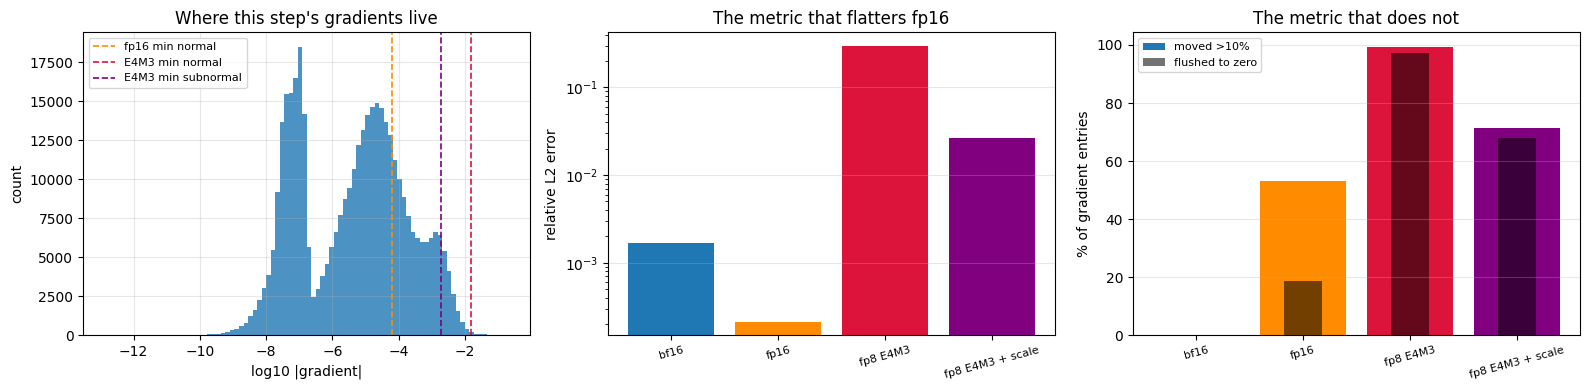

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
lg = torch.log10(nz[:400_000].float().cpu()).numpy()
ax[0].hist(lg, bins=90, color="C0", alpha=0.8)
for thr, lab, col in [(FP16_MIN_NORMAL, "fp16 min normal", "darkorange"),
                      (E4M3_MIN_NORMAL, "E4M3 min normal", "crimson"),
                      (E4M3_MIN_SUB, "E4M3 min subnormal", "purple")]:
    ax[0].axvline(math.log10(thr), color=col, ls="--", lw=1.2, label=lab)
ax[0].set_xlabel("log10 |gradient|"); ax[0].set_ylabel("count")
ax[0].set_title("Where this step's gradients live")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

# Two panels, deliberately: the metric that flatters fp16 and the metric that does not.
grows = [r for r in cast_rows if r["tensor"] == "gradients"]
names = [r["fmt"] for r in grows]
cols = ["C0", "darkorange", "crimson", "purple"]
ax[1].bar(range(len(grows)), [r["rel"] for r in grows], color=cols)
ax[1].set_yscale("log")
ax[1].set_xticks(range(len(names)))
ax[1].set_xticklabels(names, fontsize=8, rotation=15)
ax[1].set_ylabel("relative L2 error")
ax[1].set_title("The metric that flatters fp16")
ax[1].grid(alpha=0.3, axis="y")

ax[2].bar(range(len(grows)), [r["bad"] for r in grows], color=cols, label="moved >10%")
ax[2].bar(range(len(grows)), [r["zeroed"] for r in grows], color="k", alpha=0.55,
          width=0.35, label="flushed to zero")
ax[2].set_xticks(range(len(names)))
ax[2].set_xticklabels(names, fontsize=8, rotation=15)
ax[2].set_ylabel("% of gradient entries")
ax[2].set_title("The metric that does not")
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "formats.png"), dpi=140)
show(fig)


300 steps in fp32 and in bf16 autocast, same seed, same batches   [t+7m16s]
                         final loss   mean last 20   wall clock   speedup
--------------------------------------------------------------------------------------------
fp32 (TF32 matmuls)          4.8339         4.9255        14.5s     1.00x
bf16 autocast                4.8376         4.9240        12.2s     1.20x

loss difference over the last 20 steps: -0.0015 nats (0.03%)


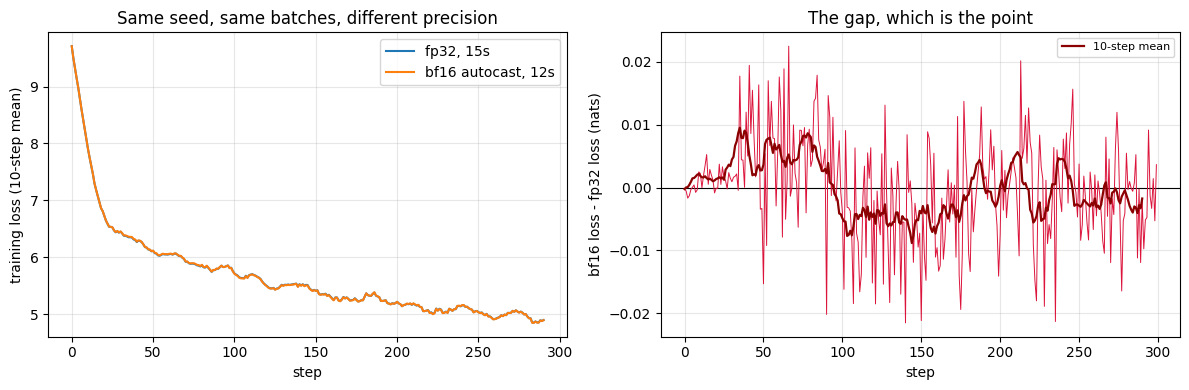

In [48]:
# ---------------------------------------------------------------------------------------
# Finally, the decision measured rather than argued: train the same model twice, fp32 and
# bf16 autocast, same seed, same data, and compare both the loss and the wall clock.
# ---------------------------------------------------------------------------------------
def train_precision(amp, steps=300, batch=8):
    torch.manual_seed(SEED)
    m = GPT(cfg).to(device)
    m.train()
    o = torch.optim.AdamW(m.parameters(), lr=6e-4, betas=(0.9, 0.95), weight_decay=0.1)
    g = torch.Generator().manual_seed(SEED + 3)
    hist = []
    torch.cuda.synchronize() if device.type == "cuda" else None
    t0 = time.perf_counter()
    for k in range(steps):
        x, y = get_batch("train", batch, cfg.block_size, generator=g)
        with (torch.autocast("cuda", dtype=amp) if amp else
              torch.autocast("cuda", enabled=False)):
            _, l = m(x, y)
        m.zero_grad(set_to_none=True)
        l.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        o.step()
        hist.append(l.item())
    torch.cuda.synchronize() if device.type == "cuda" else None
    return hist, time.perf_counter() - t0, m


torch.backends.cuda.matmul.allow_tf32 = True
h32, t32s, _ = train_precision(None)
hbf, tbfs, _ = train_precision(torch.bfloat16)

rule("300 steps in fp32 and in bf16 autocast, same seed, same batches")
print(f"{'':<22} {'final loss':>12} {'mean last 20':>14} {'wall clock':>12} {'speedup':>9}")
print("-" * 92)
print(f"{'fp32 (TF32 matmuls)':<22} {h32[-1]:>12.4f} {np.mean(h32[-20:]):>14.4f} "
      f"{t32s:>11.1f}s {'1.00x':>9}")
print(f"{'bf16 autocast':<22} {hbf[-1]:>12.4f} {np.mean(hbf[-20:]):>14.4f} "
      f"{tbfs:>11.1f}s {t32s / tbfs:>8.2f}x")
print(f"\nloss difference over the last 20 steps: "
      f"{np.mean(hbf[-20:]) - np.mean(h32[-20:]):+.4f} nats "
      f"({100 * abs(np.mean(hbf[-20:]) - np.mean(h32[-20:])) / np.mean(h32[-20:]):.2f}%)")
record("prec_fp32_final", float(np.mean(h32[-20:])))
record("prec_bf16_final", float(np.mean(hbf[-20:])))
record("prec_fp32_secs", round(t32s, 1))
record("prec_bf16_secs", round(tbfs, 1))
record("prec_speedup", round(t32s / tbfs, 2))
record("prec_loss_delta", float(np.mean(hbf[-20:]) - np.mean(h32[-20:])))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
k = 10
sm = lambda v: np.convolve(v, np.ones(k) / k, mode="valid")
ax[0].plot(sm(h32), label=f"fp32, {t32s:.0f}s")
ax[0].plot(sm(hbf), label=f"bf16 autocast, {tbfs:.0f}s")
ax[0].set_xlabel("step"); ax[0].set_ylabel(f"training loss ({k}-step mean)")
ax[0].set_title("Same seed, same batches, different precision")
ax[0].legend(); ax[0].grid(alpha=0.3)

# The curves above sit on top of each other, which is the result -- so plot the gap, which
# is the only way to see that it is a result rather than a plotting mistake.
ax[1].axhline(0, color="k", lw=0.8)
ax[1].plot(np.asarray(hbf) - np.asarray(h32), lw=0.7, color="crimson")
ax[1].plot(sm(np.asarray(hbf) - np.asarray(h32)), lw=1.6, color="darkred",
           label=f"{k}-step mean")
ax[1].set_xlabel("step"); ax[1].set_ylabel("bf16 loss - fp32 loss (nats)")
ax[1].set_title("The gap, which is the point")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "precision.png"), dpi=140)
show(fig)

In [49]:
# ---------------------------------------------------------------------------------------
# The answer to "which one would you train in", assembled from the numbers above rather
# than from the properties of the formats.
# ---------------------------------------------------------------------------------------
rule("Which one I would train in")
_g = {r["fmt"]: r for r in cast_rows if r["tensor"] == "gradients"}
print("bf16 for the compute; fp32 for the master weights, the optimizer state and the loss.")
print()
print("The case, in the order the measurements make it:")
print(f"  1. Range is what gradients need, and range is what bf16 keeps. bf16 has fp32's")
print(f"     own 8 exponent bits, so 0.00% of this step's {grads.numel():,} gradient")
print(f"     entries fall below its smallest normal. fp16 has 5 exponent bits, and")
print(f"     {100.0 * (ag < FP16_MIN_NORMAL).float().mean().item():.1f}% of them fall below "
      f"*its* smallest normal.")
print(f"  2. Resolution is what bf16 gives up, and it turns out not to matter. Casting the")
print(f"     real gradient to bf16 costs {_g['bf16']['rel']:.1e} relative L2 error, moves "
      f"{_g['bf16']['bad']:.2f}% of entries")
print(f"     by more than 10%, and flushes {_g['bf16']['zeroed']:.2f}% to zero.")
print(f"  3. fp16's better L2 error is a trap. It reads {_g['fp16']['rel']:.1e} -- better "
      f"than bf16 -- while")
print(f"     sending {_g['fp16']['zeroed']:.2f}% of the entries to exactly zero, because L2 "
      f"error is set by the")
print(f"     largest entries and the smallest ones are where the rare-token updates live.")
print(f"     Recovering those needs loss scaling: machinery, a scale factor to tune, and a")
print(f"     failure mode (overflow, skipped steps) that bf16 simply does not have.")
print(f"  4. fp8 E4M3 is not a training format for gradients at this scale. Unscaled it")
print(f"     destroys {_g['fp8 E4M3']['zeroed']:.1f}% of them; with one scale factor per "
      f"tensor it still destroys")
print(f"     {_g['fp8 E4M3 + scale']['zeroed']:.1f}%. Its 3 mantissa bits also put "
      f"{RESULTS['fp8_rel_err_0p1']:.1f}% of error on a number as")
print(f"     ordinary as 0.1. It can work -- but with finer-grained scaling than one factor")
print(f"     per tensor, and on hardware that has fp8 tensor cores. This card is "
      f"sm_{RESULTS['gpu_cc'].replace('.', '')},")
print(f"     which does not, so every fp8 number above is a software cast: the numerical")
print(f"     cost with none of the speed that would justify paying it.")
print(f"  5. And it is free. Measured above: {RESULTS['prec_speedup']}x faster for "
      f"{RESULTS['prec_loss_delta']:+.4f} nats over 300 steps.")
print()
print("What stays in fp32, and why the answer is not 'bf16 everywhere': the master weights")
print("and Adam's moments. A weight update is a small number added to a large one, and")
print(f"bf16's 8 mantissa bits resolve about {2 ** -8:.4f} relative -- an update smaller than")
print("that vanishes entirely when the sum is rounded back. So: bf16 activations and")
print("matmuls, fp32 accumulation inside them, fp32 master weights, fp32 optimizer state.")
print(f"That is the {RESULTS['bytes_per_param']} bytes per parameter counted in section 1,")
print("and it is what the extra bytes are buying.")
record("decision", "bf16 compute, fp32 master weights and optimizer state")


Which one I would train in   [t+7m16s]
bf16 for the compute; fp32 for the master weights, the optimizer state and the loss.

The case, in the order the measurements make it:
  1. Range is what gradients need, and range is what bf16 keeps. bf16 has fp32's
     own 8 exponent bits, so 0.00% of this step's 16,058,112 gradient
     entries fall below its smallest normal. fp16 has 5 exponent bits, and
     81.7% of them fall below *its* smallest normal.
  2. Resolution is what bf16 gives up, and it turns out not to matter. Casting the
     real gradient to bf16 costs 1.7e-03 relative L2 error, moves 0.00% of entries
     by more than 10%, and flushes 0.00% to zero.
  3. fp16's better L2 error is a trap. It reads 2.1e-04 -- better than bf16 -- while
     sending 18.60% of the entries to exactly zero, because L2 error is set by the
     largest entries and the smallest ones are where the rare-token updates live.
     Recovering those needs loss scaling: machinery, a scale factor to tune, and

'bf16 compute, fp32 master weights and optimizer state'

## What this run produced

Every number quoted in `README.md` is read out of `results/results.json` by
`tools/render_numbers.py`, and CI fails if the two disagree. Nothing in the write-up is
typed by hand.

In [50]:
RESULTS["elapsed_s"] = round(time.time() - T_START, 1)
RESULTS["n_results_keys"] = len(RESULTS) + 1
with open(os.path.join(OUT_DIR, "results.json"), "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, indent=1, sort_keys=True, default=float)

rule("Artifacts")
for fn in sorted(os.listdir(OUT_DIR)):
    p = os.path.join(OUT_DIR, fn)
    print(f"  results/{fn:<26} {os.path.getsize(p) / 1024:>9,.1f} KiB")
print(f"\n{len(RESULTS)} recorded values, whole run {RESULTS['elapsed_s'] / 60:.1f} minutes "
      f"on {RESULTS.get('gpu') or 'CPU'}")


Artifacts   [t+7m16s]
  results/accumulation.png               116.3 KiB
  results/formats.png                     72.8 KiB
  results/gradcheck.png                   88.2 KiB
  results/gradnorm.png                   235.1 KiB
  results/mfu.png                         57.7 KiB
  results/nbexec.log                       0.7 KiB
  results/precision.png                  161.2 KiB
  results/results.json                    18.8 KiB
  results/run_log.txt                     49.5 KiB
  results/shapes_full.txt                 19.4 KiB
  results/step_log.npz                    22.6 KiB
  results/tinyshakespeare.txt          1,089.3 KiB

210 recorded values, whole run 7.3 minutes on NVIDIA GeForce RTX 3050 Laptop GPU


### The six answers, in one place

1. **Shapes.** Every tensor in the step is printed with its axes named, all four blocks are
   written to `results/shapes_full.txt`, and three audits check that the list is complete:
   every module output appears in it, every activation's gradient has the activation's own
   shape, and the traced path computes the same numbers as the fused kernel training uses.
   The step's memory is dominated by one tensor, `logits [B,T,V]`, because `V/C = 196`.

2. **One gradient by hand.** Central difference against `backward()` in float64: agreement
   to ~9 significant digits at the best step size, with the error rising on both sides of
   it — round-off on one side, truncation on the other. Ten more parameters agree to at
   least 7 digits, and a directional derivative over all 16M parameters agrees to 7. The
   same check in float32 confirms 3 digits, which is a fact about the ruler, not the
   gradient. Turning dropout on makes the check fail outright, and the section shows how to
   tell that apart from a real bug: evaluate the loss twice without changing anything.
   On the way to setting this up the check found a genuine defect — torch's fused CPU
   attention returns NaN in float64 when `dropout_p=0`.

3. **Accumulation.** The correct rule is shown to be *identical* to not accumulating at
   all. The average-of-averages rule, with ragged micro-batches, produces a gradient that
   points measurably elsewhere at equal norm, and two otherwise identical runs separate on
   a held-out, correctly-weighted loss. With equal-length micro-batches the two rules agree
   to the last bit, which is why the bug survived so long.

4. **Grad norm.** Logged every step, alongside a fixed probe batch measured *before* each
   update. The general claim does not survive: across a whole run the cross-correlation
   between the two peaks at lag 0, so on an ordinary step the norm does not lead anything.
   The lead is a property of the steps where something is going wrong. A threshold grid
   over two runs finds a single marginal natural instance, reported with its own caveats;
   the injected corrupted shard is the unambiguous one — the norm moves at the step the
   shard arrives, the loss is still exactly on trend, and it breaks two steps later.

5. **MFU.** Computed against a ceiling measured on this machine rather than a spec sheet,
   with the step broken into forward, backward, optimizer and overhead, and a ladder of
   one-change-at-a-time ablations. The distance to 40% is attributed mostly to *shape*:
   the output head is ~80% of the FLOPs and is a matmul with an inner dimension of 256.

6. **0.1.** Derived by hand in exact rational arithmetic for fp32, bf16, fp16 and fp8 E4M3,
   with the bits checked against what torch stores, and the encoder checked against torch
   over ten thousand values. The training-format decision is then made from this model's
   own gradients rather than from the table.